In [ ]:
import cv2
import pywt
import pandas as pd
import seaborn as sn
import numpy as np
from sklearn.svm import SVC
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import local_binary_pattern
from skimage.feature import graycomatrix, graycoprops
from skimage.feature import hog
from keras.models import load_model,Model
import joblib
from skimage.color import rgb2gray
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.applications import EfficientNetB0
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.callbacks import ReduceLROnPlateau


In [4]:
import os
import random
import numpy as np
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras.backend")
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"   
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "42"         
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass



In [6]:
def cnn_augmentation(img):
    img = img.astype(np.float32)
    img = cv2.GaussianBlur(img, (5,5), 1.2)
    mn, mx = img.min(), img.max()
    if mx > mn:
        img = (img - mn) / (mx - mn)
    img = img ** 0.95

    img = np.clip(img, 0, 1)
    return img.reshape(200,200)


def rf_augmentation(img):
    img = img.astype(np.float32)
    img = cv2.equalizeHist((img * 255).astype(np.uint8)) / 255.0
    img = cv2.GaussianBlur(img, (3,3), 0.8)

    img = np.clip(img, 0, 1)
    return img

def svm_augmentation(img):
    img = img.astype(np.float32)
    img = img / 255.0
    kernel = np.array([[0, -1/8, 0],
                       [-1/8, 1.5, -1/8],
                       [0, -1/8, 0]])
    img = cv2.filter2D(img, -1, kernel)
    img = np.clip(img, 0, 1)
    img = img ** 1.05

    return img



def knn_augmentation(img):
    img = img.astype(np.float32)
    img = cv2.GaussianBlur(img, (5,5), 1.0)
    mn, mx = img.min(), img.max()
    if mx > mn:
        img = (img - mn) / (mx - mn)
    kernel = np.array([
        [0, -0.25, 0],
        [-0.25, 2.0, -0.25],
        [0, -0.25, 0]
    ], dtype=np.float32)
    img = cv2.filter2D(img, -1, kernel)
    img = np.clip(img, 0, 1)
    return img


def LR_augmentation(img):
    img = img.astype(np.float32)
    img = cv2.equalizeHist((img * 255).astype(np.uint8)) / 255.0
    img = np.clip(img, 0, 1)
    return img


In [7]:
path_of_dir = os.listdir('../data/main/')
classes_in_dir = {'Brain Tumor': 1, 'Healthy': 0}

X, Y = [], []
for cls in classes_in_dir:
    path = '../data/main/' + cls
    for  file in sorted(os.listdir(path)):
        img = cv2.imread(os.path.join(path, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (200, 200))
        X.append(img)
        Y.append(classes_in_dir[cls])

x = np.array(X, dtype="float32")
y = np.array(Y)


In [5]:
x.dtype

dtype('float32')

In [6]:
x.shape

(4600, 200, 200)

In [7]:
pd.Series(y).value_counts()

1    2513
0    2087
Name: count, dtype: int64

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)


x_train = x_train / 255
x_test = x_test / 255


x_train_aug1 = np.array([cnn_augmentation(img) for img in x_train])
x_train_aug2 = np.array([rf_augmentation(img) for img in x_train])
x_train_aug3 = np.array([svm_augmentation(img) for img in x_train])
x_train_aug4 = np.array([knn_augmentation(img) for img in x_train])
x_train_aug5 = np.array([LR_augmentation(img) for img in x_train])


def combine_with_labels(x_orig, y_orig, x_aug):
    x_comb = np.concatenate([x_orig, x_aug], axis=0)
    y_comb = np.concatenate([y_orig, y_orig], axis=0)  
    return x_comb, y_comb

x_train_cnn, y_train_cnn = combine_with_labels(x_train, y_train, x_train_aug1)  
x_train_rf,  y_train_rf  = combine_with_labels(x_train, y_train, x_train_aug2)  
x_train_svm, y_train_svm = combine_with_labels(x_train, y_train, x_train_aug3)  
x_train_knn, y_train_knn = combine_with_labels(x_train, y_train, x_train_aug4)  
x_train_lr,  y_train_lr  = combine_with_labels(x_train, y_train, x_train_aug5)  


x_train_cnn = x_train_cnn.reshape(-1, 200, 200, 1) 
x_test_cnn  = x_test.reshape(-1, 200, 200, 1)


x_train_rf  = x_train_rf.reshape(-1, 200, 200) 
x_train_svm = x_train_svm.reshape(-1, 200, 200) 
x_train_knn = x_train_knn.reshape(-1, 200, 200) 
x_train_lr  = x_train_lr.reshape(-1, 200, 200) 
x_test_ml   = x_test.reshape(-1, 200, 200)   


y_train_cnn = np.array(y_train_cnn)
y_train_rf  = np.array(y_train_rf)
y_train_svm = np.array(y_train_svm)
y_train_knn = np.array(y_train_knn)
y_train_lr  = np.array(y_train_lr)
y_test      = np.array(y_test)


print("CNN Train:", x_train_cnn.shape, y_train_cnn.shape)
print("RF Train :", x_train_rf.shape,  y_train_rf.shape)
print("SVM Train:", x_train_svm.shape, y_train_svm.shape)
print("KNN Train:", x_train_knn.shape, y_train_knn.shape)
print("LR Train :", x_train_lr.shape,  y_train_lr.shape)
print("CNN Test :", x_test_cnn.shape, y_test.shape)
print("ML Test  :", x_test_ml.shape, y_test.shape)


CNN Train: (7360, 200, 200, 1) (7360,)
RF Train : (7360, 200, 200) (7360,)
SVM Train: (7360, 200, 200) (7360,)
KNN Train: (7360, 200, 200) (7360,)
LR Train : (7360, 200, 200) (7360,)
CNN Test : (920, 200, 200, 1) (920,)
ML Test  : (920, 200, 200) (920,)


#CNN MODEL

In [9]:
cnn = Sequential([
    Conv2D(8, (3,3), activation='relu', padding='same', input_shape=(200,200,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(8, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(16, activation='relu'),
    Dropout(0.5),       

    Dense(1, activation='sigmoid')
])


In [10]:
cnn.compile(optimizer=Adam(learning_rate = 1e-5),loss='binary_crossentropy', metrics=['accuracy'])

In [11]:
s = cnn.fit( x_train_cnn, y_train_cnn,validation_data=(x_test_cnn, y_test),epochs=15,batch_size=32)

Epoch 1/15
230/230 [==============================] - 39s 146ms/step - loss: 0.6796 - accuracy: 0.6141 - val_loss: 0.6528 - val_accuracy: 0.5957
Epoch 2/15
230/230 [==============================] - 31s 136ms/step - loss: 0.5571 - accuracy: 0.7058 - val_loss: 0.5140 - val_accuracy: 0.7598
Epoch 3/15
230/230 [==============================] - 30s 131ms/step - loss: 0.4942 - accuracy: 0.7478 - val_loss: 0.4118 - val_accuracy: 0.8207
Epoch 4/15
230/230 [==============================] - 29s 127ms/step - loss: 0.4480 - accuracy: 0.7825 - val_loss: 0.3618 - val_accuracy: 0.8446
Epoch 5/15
230/230 [==============================] - 29s 125ms/step - loss: 0.4051 - accuracy: 0.8073 - val_loss: 0.3159 - val_accuracy: 0.8565
Epoch 6/15
230/230 [==============================] - 29s 125ms/step - loss: 0.3678 - accuracy: 0.8279 - val_loss: 0.2839 - val_accuracy: 0.8946
Epoch 7/15
230/230 [==============================] - 29s 125ms/step - loss: 0.3368 - accuracy: 0.8471 - val_loss: 0.2591 - val_ac

In [12]:
test_loss, test_acc = cnn.evaluate(x_test_cnn, y_test,  verbose=2)
print("validation Loss:", test_loss)
print("validation  Accuracy:", test_acc)

29/29 - 2s - loss: 0.1610 - accuracy: 0.9478 - 2s/epoch - 61ms/step
validation Loss: 0.1610325127840042
validation  Accuracy: 0.947826087474823


In [13]:
train_loss_list = s.history['loss']
val_loss_list = s.history['val_loss']

for epoch in range(len(train_loss_list)):
    print(f"Epoch {epoch+1}: loss = {train_loss_list[epoch]:.4f}, "
          f"val_loss = {val_loss_list[epoch]:.4f}")


Epoch 1: loss = 0.6796, val_loss = 0.6528
Epoch 2: loss = 0.5571, val_loss = 0.5140
Epoch 3: loss = 0.4942, val_loss = 0.4118
Epoch 4: loss = 0.4480, val_loss = 0.3618
Epoch 5: loss = 0.4051, val_loss = 0.3159
Epoch 6: loss = 0.3678, val_loss = 0.2839
Epoch 7: loss = 0.3368, val_loss = 0.2591
Epoch 8: loss = 0.3159, val_loss = 0.2428
Epoch 9: loss = 0.2983, val_loss = 0.2237
Epoch 10: loss = 0.2736, val_loss = 0.2076
Epoch 11: loss = 0.2622, val_loss = 0.2021
Epoch 12: loss = 0.2422, val_loss = 0.1841
Epoch 13: loss = 0.2358, val_loss = 0.1761
Epoch 14: loss = 0.2233, val_loss = 0.1668
Epoch 15: loss = 0.2064, val_loss = 0.1610


In [14]:
pred1=(cnn.predict(x_test_cnn)>0.5).astype('int').flatten()

29/29 [==============================] - 2s 55ms/step


In [15]:
cnn_acc=accuracy_score(y_test,pred1)

In [16]:
classes = [f"Class {i}" for i in np.unique(y_test)]


In [17]:
conf_mat= confusion_matrix(y_test,pred1)
print(classification_report(y_test,pred1,zero_division=0))


              precision    recall  f1-score   support

           0       0.95      0.93      0.94       417
           1       0.94      0.96      0.95       503

    accuracy                           0.95       920
   macro avg       0.95      0.95      0.95       920
weighted avg       0.95      0.95      0.95       920



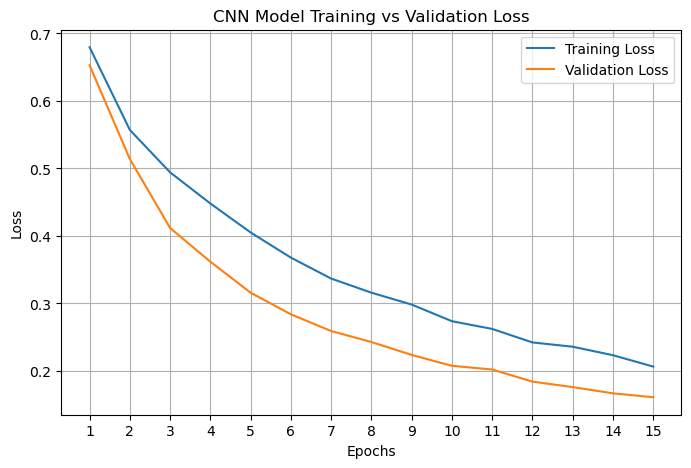

In [18]:
train_loss = train_loss_list
val_loss   = val_loss_list

epochs = range(1, 16)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])
plt.title("CNN Model Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


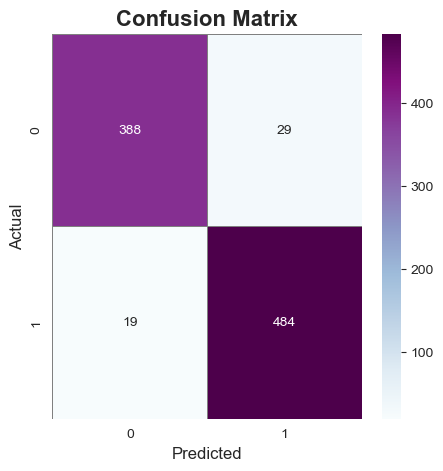

In [19]:
plt.figure(figsize=(5,5))
sn.set_style("whitegrid")
sn.heatmap(conf_mat, annot=True, fmt='d', cmap="BuPu",linewidths=0.5, linecolor='gray')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.title('Confusion Matrix', fontsize=16, weight='bold')
plt.show()


EfficientNet Model


In [ ]:
# ------------------------------
# 1. Preprocessing function for tf.data
# ------------------------------
def preprocess(x, y):
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    if x.shape[-1] == 1:
        x = tf.squeeze(x, axis=-1)         # remove extra channel dim → (H,W)
    x = tf.expand_dims(x, axis=-1)        # (H,W,1)
    x = tf.image.grayscale_to_rgb(x)      # (H,W,3)
    x = x / 255.0
    return x, y

batch_size = 16

train_ds = tf.data.Dataset.from_tensor_slices((x_train_cnn, y_train_cnn))
train_ds = train_ds.map(preprocess).shuffle(500).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_test_cnn, y_test))
val_ds = val_ds.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)



In [18]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(200,200,3))

# Freeze all layers except last 20 for fine-tuning
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Add top layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)                       # add dropout to reduce overfitting
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# ------------------------------
# 2. Compile
# ------------------------------
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])


In [19]:

history = model.fit(train_ds, validation_data=val_ds, epochs=10,verbose=2 )


Epoch 1/10
460/460 - 245s - loss: 0.6981 - accuracy: 0.5261 - val_loss: 0.6892 - val_accuracy: 0.5467 - 245s/epoch - 532ms/step
Epoch 2/10
460/460 - 225s - loss: 0.6946 - accuracy: 0.5314 - val_loss: 0.6888 - val_accuracy: 0.5467 - 225s/epoch - 488ms/step
Epoch 3/10
460/460 - 210s - loss: 0.6911 - accuracy: 0.5404 - val_loss: 0.6890 - val_accuracy: 0.5467 - 210s/epoch - 457ms/step
Epoch 4/10
460/460 - 205s - loss: 0.6906 - accuracy: 0.5399 - val_loss: 0.6893 - val_accuracy: 0.5467 - 205s/epoch - 446ms/step
Epoch 5/10
460/460 - 226s - loss: 0.6913 - accuracy: 0.5356 - val_loss: 0.6893 - val_accuracy: 0.5467 - 226s/epoch - 492ms/step
Epoch 6/10
460/460 - 230s - loss: 0.6919 - accuracy: 0.5401 - val_loss: 0.6891 - val_accuracy: 0.5467 - 230s/epoch - 500ms/step
Epoch 7/10
460/460 - 229s - loss: 0.6903 - accuracy: 0.5455 - val_loss: 0.6888 - val_accuracy: 0.5467 - 229s/epoch - 499ms/step
Epoch 8/10
460/460 - 229s - loss: 0.6900 - accuracy: 0.5443 - val_loss: 0.6888 - val_accuracy: 0.5467 - 

LSTM

In [ ]:

# -----------------------------
# 1. Example dataset: sequence classification
# -----------------------------
# Suppose each sample is a sequence of length 100 with 1 feature
num_samples = 1000
timesteps = 100
features = 1

# Random sequence data
X = np.random.rand(num_samples, timesteps, features).astype(np.float32)

# Binary labels
y = np.random.randint(0, 2, size=(num_samples, 1))

# Split into train/test
split = int(0.8 * num_samples)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -----------------------------
# 2. Build LSTM model
# -----------------------------
model = Sequential([
    LSTM(64, input_shape=(timesteps, features), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 3. Callbacks
# -----------------------------
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# -----------------------------
# 4. Train
# -----------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[reduce_lr],
    verbose=2
)

# -----------------------------
# 5. Evaluate
# -----------------------------
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 64)           16896     
                                                                 
 dropout_1 (Dropout)         (None, 100, 64)           0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_6 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29,345
Trainable params: 29,345
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
25/25 - 4s - loss: 0.6939 - accuracy: 0.4

In [ ]:
# Save model saved
if not os.path.exists("cnn_for_new_identification.h5"):
    cnn.save("cnn_for_new_identification.h5")
    print("CNN saved.")
else:
    print("CNN model already exists")

CNN saved.


In [ ]:
cnn_model_path = "cnn_for_new_identification.h5"

#Random forest

In [ ]:
# ------------------ CNN Features ------------------
def extract_cnn_features(images, cnn_model_path, batch_size=32):

    cnn = load_model(cnn_model_path, compile=False)

    # Freeze all layers, disable BatchNorm & Dropout randomness
    for layer in cnn.layers:
        layer.trainable = False
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer._per_input_updates = {}
            layer._assign_moving_average = lambda *args, **kwargs: None
        if isinstance(layer, tf.keras.layers.Dropout):
            layer.rate = 0.0

    feature_layer = cnn.layers[-3].output  # layer before final dense
    feature_model = Model(inputs=cnn.input, outputs=feature_layer)

    if images.ndim == 3:
        images = images[..., np.newaxis]

    images = images.astype(np.float32) / 255.0   # single normalization

    feats = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        batch_feat = feature_model(batch, training=False)
        feats.append(batch_feat.numpy().reshape(len(batch_feat), -1))

    return np.vstack(feats).astype(np.float32)

# ------------------ Wavelet Features ------------------
def extract_wavelet_features(images, wavelet="db2", level=2):

    feats = []
    for img in images:
        img = img.astype(np.float32)
        coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
        cA = coeffs[0]
        cH, cV, cD = coeffs[1]

        feat = np.hstack([
            np.nan_to_num(cA).ravel(),
            np.nan_to_num(cH).ravel()
        ])
        feats.append(feat)

    return np.array(feats, dtype=np.float32)

# ------------------ HOG Features ------------------
def extract_hog_features(images):

    feats = []
    for img in images:
        img = np.float32(img) / 255.0
        feat = hog(
            img,
            orientations=8,
            pixels_per_cell=(16,16),
            cells_per_block=(1,1),
            block_norm="L2-Hys",
            visualize=False,
            feature_vector=True
        )
        feats.append(np.nan_to_num(feat))

    return np.array(feats, dtype=np.float32)

# ------------------ Hybrid Features ------------------
def extract_hybrid_features(images, cnn_model_path):

    wave = extract_wavelet_features(images)
    hogf = extract_hog_features(images)
    cnnf = extract_cnn_features(images, cnn_model_path)

    n = min(len(wave), len(hogf), len(cnnf))
    hybrid = np.hstack([wave[:n], hogf[:n], cnnf[:n]])
    return np.nan_to_num(hybrid).astype(np.float32)


In [ ]:
X_train_hog1 = extract_hybrid_features(x_train_rf, cnn_model_path)
X_test_hog1  = extract_hybrid_features(x_test_ml, cnn_model_path)
print("HOG train shape:", X_train_hog1.shape)
print("HOG test shape :", X_test_hog1.shape)

pca_rf = PCA(n_components=50)  
X_train_pca_rf = pca_rf.fit_transform(X_train_hog1)
X_test_pca_rf = pca_rf.transform(X_test_hog1)

scaler_rf_2 = StandardScaler()
X_train_scaled2 = scaler_rf_2.fit_transform(X_train_pca_rf)
X_test_scaled2 = scaler_rf_2.transform(X_test_pca_rf)

rf = RandomForestClassifier(n_estimators=7, random_state=42)

rf.fit(X_train_scaled2 , y_train_rf)

pred2 = rf.predict(X_test_scaled2)
Rf_acc= accuracy_score(y_test, pred2)
print("Train  Accuracy:", rf.score(X_train_scaled2 , y_train_rf))
print("RF (HOG) Test Accuracy:",Rf_acc )
print("\nClassification Report (HOG):\n", classification_report(y_test, pred2))


HOG train shape: (7360, 6576)
HOG test shape : (920, 6576)
Train  Accuracy: 0.9980978260869565
RF (HOG) Test Accuracy: 0.9597826086956521

Classification Report (HOG):
               precision    recall  f1-score   support

           0       0.97      0.94      0.96       417
           1       0.95      0.97      0.96       503

    accuracy                           0.96       920
   macro avg       0.96      0.96      0.96       920
weighted avg       0.96      0.96      0.96       920



In [ ]:

conf_mat2=confusion_matrix(y_test,pred2)


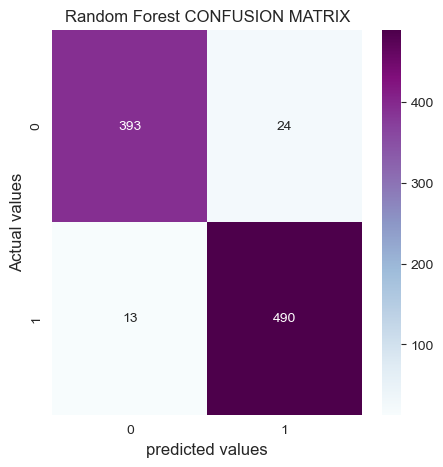

In [ ]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True,fmt='d',cmap="BuPu")
plt.xlabel('predicted values',fontsize=12)
plt.ylabel("Actual values",fontsize=12)
plt.title("Random Forest CONFUSION MATRIX",fontsize=12)
plt.show()

#SVM

In [ ]:
# Extract features
X_train_hog2 = extract_hybrid_features(x_train_svm, cnn_model_path)
X_test_hog2  = extract_hybrid_features(x_test_ml, cnn_model_path)
print("Train shape:", X_train_hog2.shape)
print("Test shape :", X_test_hog2.shape)

pca_svm = PCA(n_components=800)   
X_train_pca_svm = pca_svm.fit_transform(X_train_hog2)
X_test_pca_svm = pca_svm.transform(X_test_hog2)


scaler_svm = StandardScaler() 
X_train_hog22 = scaler_svm.fit_transform(X_train_pca_svm)
X_test_hog22  = scaler_svm.transform(X_test_pca_svm )

svm = SVC( C=1e-3, kernel='linear', class_weight="balanced",   probability=True , random_state=42 )
svm.fit(X_train_hog22, y_train_svm)

# Predict
pred3 = svm.predict(X_test_hog22)
svm_acc = accuracy_score(y_test, pred3)
print("Train Accuracy:", svm.score(X_train_hog22, y_train_svm))
print("Test Accuracy :",svm_acc )
print("\nClassification Report:\n", classification_report(y_test, pred3))

Train shape: (7360, 6576)
Test shape : (920, 6576)
Train Accuracy: 0.9247282608695652
Test Accuracy : 0.9315217391304348

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93       417
           1       0.96      0.91      0.94       503

    accuracy                           0.93       920
   macro avg       0.93      0.93      0.93       920
weighted avg       0.93      0.93      0.93       920



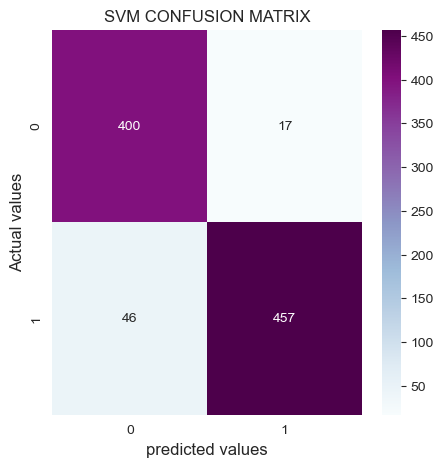

In [ ]:
conf_mat3=confusion_matrix(y_test,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True,fmt='d',cmap="BuPu")
plt.xlabel('predicted values',fontsize=12)
plt.ylabel("Actual values",fontsize=12)
plt.title("SVM CONFUSION MATRIX",fontsize=12)
plt.show()

#KNN

In [ ]:
X_train_hog3 = extract_hybrid_features(x_train_rf, cnn_model_path)
X_test_hog3  = extract_hybrid_features(x_test_ml, cnn_model_path)

pca_knn = PCA(n_components=100)  
X_train_pca_knn = pca_knn.fit_transform(X_train_hog3)
X_test_pca_knn = pca_knn.transform(X_test_hog3)

scaler_knn = StandardScaler()
X_train_scaled4 = scaler_knn.fit_transform(X_train_pca_knn)
X_test_scaled4  = scaler_knn.transform(X_test_pca_knn)

knn = KNeighborsClassifier(n_neighbors=3,  weights='distance',metric='manhattan')
knn.fit(X_train_scaled4, y_train_knn)

pred4 = knn.predict(X_test_scaled4 )
Knn_acc= accuracy_score(y_test, pred4)
print("Train Accuracy:", knn.score(X_train_scaled4 , y_train_knn))
print("Test Accuracy:",Knn_acc)
print("\nClassification Report:\n", classification_report(y_test, pred4))


Train Accuracy: 1.0
Test Accuracy: 0.9706521739130435

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       417
           1       0.97      0.98      0.97       503

    accuracy                           0.97       920
   macro avg       0.97      0.97      0.97       920
weighted avg       0.97      0.97      0.97       920



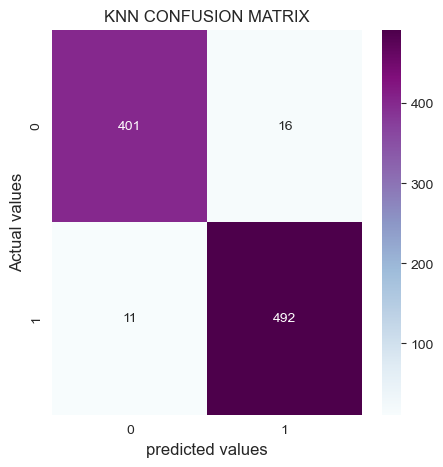

In [ ]:
conf_mat4=confusion_matrix(y_test,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True,fmt='d',cmap="BuPu")
plt.xlabel('predicted values' ,fontsize=12)
plt.ylabel("Actual values",fontsize=12)
plt.title("KNN CONFUSION MATRIX",fontsize=12)
plt.show()

#Logistic Regression

In [ ]:

X_train_feats5 = extract_hybrid_features(x_train_lr, cnn_model_path)
X_test_feats5 = extract_hybrid_features(x_test_ml, cnn_model_path)


print("Feature shapes -> Train:", X_train_feats5.shape, "Test:", X_test_feats5.shape)

pca_LR = PCA(n_components=800)  
X_train_pca_LR = pca_LR.fit_transform(X_train_feats5)
X_test_pca_LR = pca_LR.transform(X_test_feats5)

scaler_LR = StandardScaler()
X_train_scaled5 = scaler_LR.fit_transform(X_train_pca_LR )
X_test_scaled5 = scaler_LR.transform(X_test_pca_LR)


LogR = LogisticRegression(
    C=0.001,                 
    solver="liblinear",
    penalty="l2",
    max_iter=2000,
    class_weight="balanced" , random_state=42 

)

LogR.fit(X_train_scaled5, y_train_lr)

pred5  = LogR.predict(X_test_scaled5)
Lr_acc= accuracy_score(y_test, pred5)
print("Train Accuracy:", LogR.score(X_train_scaled5, y_train_lr))
print("Test  Accuracy:", Lr_acc)
print("\nClassification Report:\n", classification_report(y_test, pred5))


Feature shapes -> Train: (7360, 6576) Test: (920, 6576)
Train Accuracy: 0.9797554347826087
Test  Accuracy: 0.9206521739130434

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.92       417
           1       0.95      0.90      0.93       503

    accuracy                           0.92       920
   macro avg       0.92      0.92      0.92       920
weighted avg       0.92      0.92      0.92       920



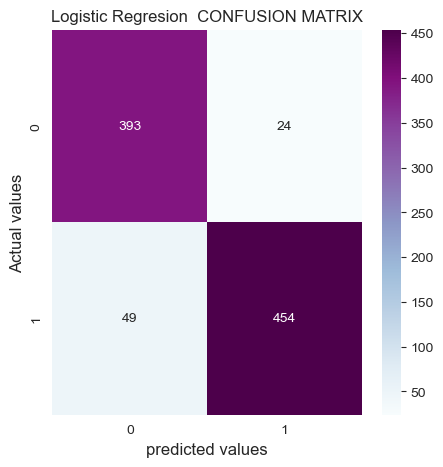

In [ ]:
conf_mat5= confusion_matrix(y_test,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True,fmt='d', cmap="BuPu" )
plt.xlabel('predicted values',fontsize=12)
plt.ylabel("Actual values",fontsize=12)
plt.title("Logistic Regresion  CONFUSION MATRIX",fontsize=12)
plt.show()

In [ ]:
# ---- Save RF ----
if not os.path.exists("rf_new_model.pkl"):
    joblib.dump(rf, "rf_new_model.pkl")
    print("RF saved.")
else:
    print("RF model already exists")

# ---- Save SVM ----
if not os.path.exists("svm_new_model.pkl"):
    joblib.dump(svm, "svm_new_model.pkl")
    print("SVM saved.")
else:
    print("SVM model already exists")

# ---- Save KNN ----
if not os.path.exists("knn_new_model.pkl"):
    joblib.dump(knn, "knn_new_model.pkl")
    print("KNN saved.")
else:
    print("KNN model already exists")
# ---- Save Logistic Regression ----
if not os.path.exists("logr_new_model.pkl"):
    joblib.dump(LogR, "logr_new_model.pkl")
    print("Logistic Regression model saved.")
else:
    print("Logistic Regression model already exists")



# ---- Save Logistic Regression ----
if not os.path.exists("scaler_svm .pkl"):
    joblib.dump(scaler_svm, "scaler_svm .pkl")
    print("scaler_svm  saved.")
else:
    print("scaler_svm already exists")

if not os.path.exists("scaler_rf_new_model.pkl"):
    joblib.dump(scaler_rf_2, "scaler_rf_new_model.pkl")
    print("scaler random forest model  saved.")
else:
    print("scaler random forest  model already exists")

if not os.path.exists("scaler_knn_new_model.pkl"):
    joblib.dump(scaler_knn, "scaler_knn_new_model.pkl")
    print("scaler KNN model  saved.")
else:
    print("scaler KNN  model already exists")

if not os.path.exists("scaler_LR_new_model.pkl"):
    joblib.dump(scaler_LR, "scaler_LR_new_model.pkl")
    print("scaler LR model  saved.")
else:
    print("scaler LR  model already exists")



if not os.path.exists("PCA_LR_new_model.pkl"):
    joblib.dump(pca_LR, "PCA_LR_new_model.pkl")
    print("PCA LR model  saved.")
else:
    print("PCA LR  model already exists")
if not os.path.exists("PCA_KNN_new_model.pkl"):
    joblib.dump(pca_knn, "PCA_KNN_new_model.pkl")
    print("PCA KNN model  saved.")
else:
    print("PCA KNN  model already exists")
if not os.path.exists("PCA_SVM_new_model.pkl"):
    joblib.dump(pca_svm, "PCA_SVM_new_model.pkl")
    print("PCA SVM model  saved.")
else:
    print("PCA SVM  model already exists")

if not os.path.exists("PCA_RF_new_model.pkl"):
    joblib.dump(pca_rf, "PCA_RF_new_model.pkl")
    print("PCA RF model  saved.")
else:
    print("PCA RF  model already exists")

RF saved.
SVM saved.
KNN saved.
Logistic Regression model saved.
scaler_svm  saved.
scaler random forest model  saved.
scaler KNN model  saved.
scaler LR model  saved.
PCA LR model  saved.
PCA KNN model  saved.
PCA SVM model  saved.
PCA RF model  saved.


# ALL PREDICTED VALUES

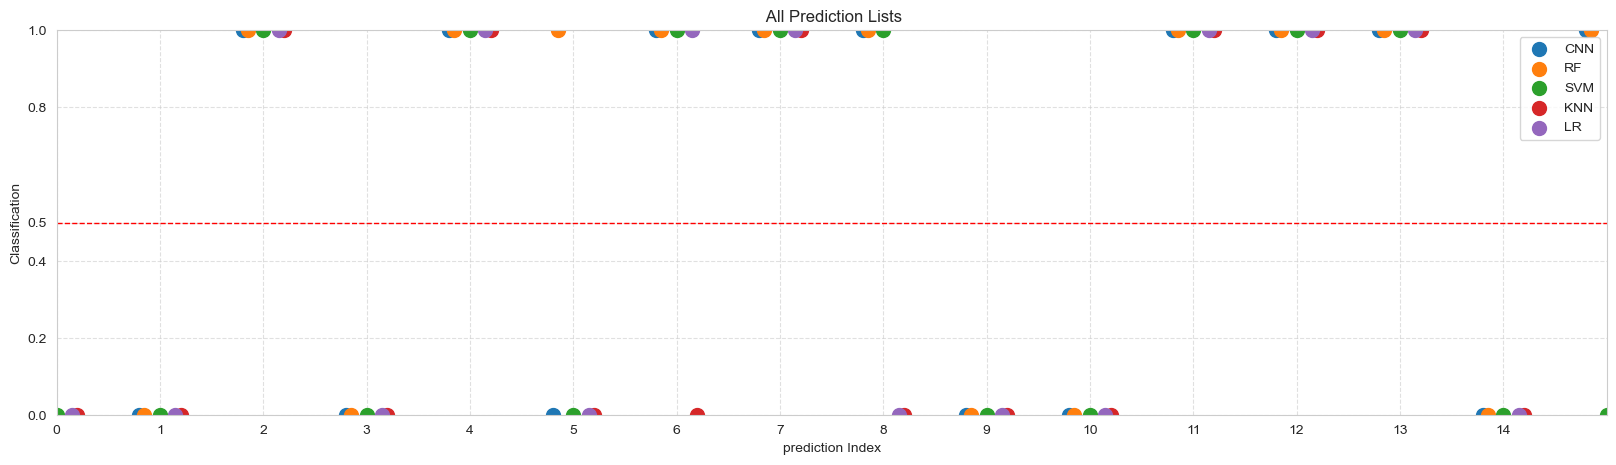

In [33]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=100)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=100)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=100)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=100)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=100)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,15)
plt.xticks(range(0,15))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [34]:
X_test_rf2  = extract_hybrid_features(x_test_ml, cnn_model_path)
x_test_rf_pca= pca_rf.transform(X_test_rf2)
X_test_scaled_rf = scaler_rf_2.transform(x_test_rf_pca)


X_test_svm3  = extract_hybrid_features(x_test_ml, cnn_model_path)
x_test_svm_pca=pca_svm.transform(X_test_svm3)
x_test_svm_scal=scaler_svm.transform(x_test_svm_pca)


X_ext_knn4 =  extract_hybrid_features(x_test_ml, cnn_model_path)
x_test_KNN_pca=pca_knn.transform(X_ext_knn4)
X_scaledknn4 = scaler_knn.transform(x_test_KNN_pca)

X_ext_lr5 = extract_hybrid_features(x_test_ml, cnn_model_path)
x_test_LR_pca=pca_LR.transform(X_ext_lr5)
x_test_LR_scal=scaler_LR.transform(x_test_LR_pca)


pp1 = cnn.predict(x_test_cnn).flatten()           
pp2 = rf.predict_proba(X_test_scaled_rf)[:,1]     
pp3 = svm.predict_proba(x_test_svm_scal)[:,1]
pp4 = knn.predict_proba(X_scaledknn4)[:,1]
pp5 = LogR.predict_proba(x_test_LR_scal)[:,1]


29/29 [==============================] - 2s 47ms/step


In [35]:
print(f"CNN={cnn_acc:.3f}  RF={Rf_acc:.3f}  SVM={svm_acc:.3f}  KNN={Knn_acc:.3f}  LR={Lr_acc:.3f}")


CNN=0.948  RF=0.960  SVM=0.932  KNN=0.971  LR=0.921



Weights used for soft voting: [0.20036765 0.20289522 0.19692096 0.20519301 0.19462316]
Shapes:
y_test: (920,)
pp1: (920,)
pp2: (920,)
pp3: (920,)
pp4: (920,)
pp5: (920,)
Preds shape: (920, 5)
weighted_sum shape: (920,)

Weighted Soft Voting Ensemble Accuracy: 0.975

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       417
           1       0.97      0.98      0.98       503

    accuracy                           0.97       920
   macro avg       0.98      0.97      0.97       920
weighted avg       0.98      0.97      0.97       920


Confusion Matrix:
 [[402  15]
 [  8 495]]


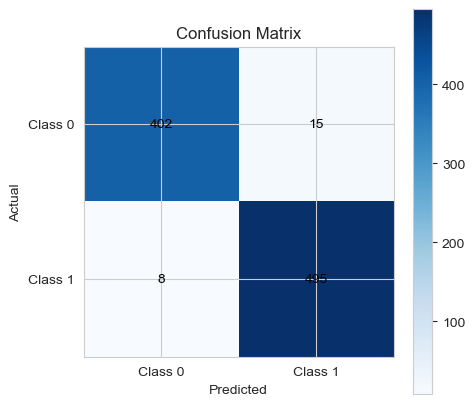

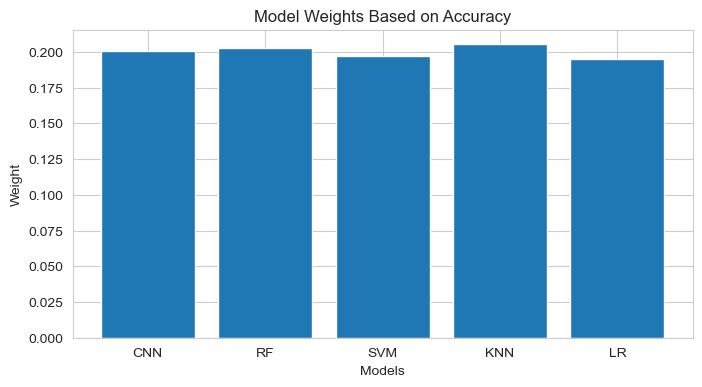

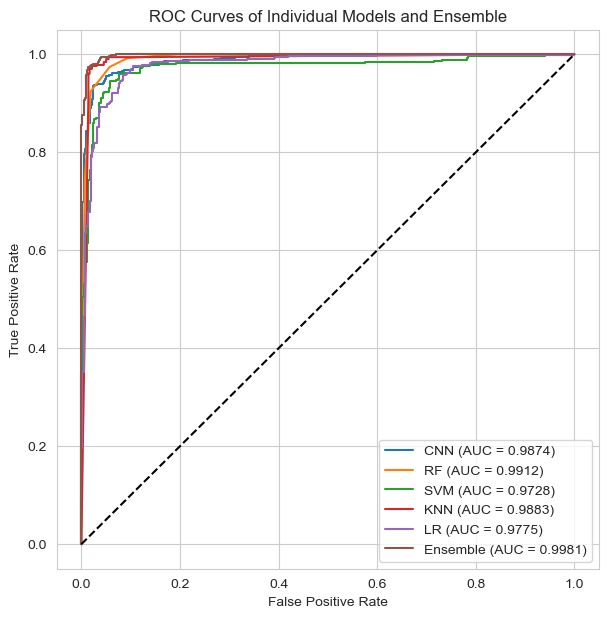

In [36]:
accuracies = np.array([cnn_acc, Rf_acc, svm_acc, Knn_acc, Lr_acc], dtype=float)

if accuracies.sum() == 0:
    accuracies = np.ones_like(accuracies)


weights1 = accuracies / accuracies.sum()
print("\nWeights used for soft voting:", weights1)

print("Shapes:")
print("y_test:", y_test.shape)
print("pp1:", pp1.shape)
print("pp2:", pp2.shape)
print("pp3:", pp3.shape)
print("pp4:", pp4.shape)
print("pp5:", pp5.shape)


preds = np.vstack([pp1, pp2, pp3, pp4, pp5]).T
print("Preds shape:", preds.shape)      


weighted_sum81 = np.dot(preds, weights1)
print("weighted_sum shape:", weighted_sum81.shape)   


Ensemble_prediction = (weighted_sum81 >= 0.5).astype(int)

ens_acc = accuracy_score(y_test, Ensemble_prediction)
print("\nWeighted Soft Voting Ensemble Accuracy:", ens_acc)


print("\nClassification Report:")
print(classification_report(y_test, Ensemble_prediction))


cm = confusion_matrix(y_test, Ensemble_prediction)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

labels = ["CNN","RF","SVM","KNN","LR"]

plt.figure(figsize=(8,4))
plt.bar(labels, weights1)
plt.title("Model Weights Based on Accuracy")
plt.ylabel("Weight")
plt.xlabel("Models")
plt.show()

models = {
    "CNN": pp1,
    "RF": pp2,
    "SVM": pp3,
    "KNN": pp4,
    "LR": pp5,
    "Ensemble": weighted_sum81
}

plt.figure(figsize=(7,7))

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Individual Models and Ensemble")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [37]:
g=np.where(y_test != Ensemble_prediction)[0]
print(g)

[ 20  51 111 183 212 288 318 392 427 442 481 524 531 541 571 634 693 778
 786 796 818 825 890]


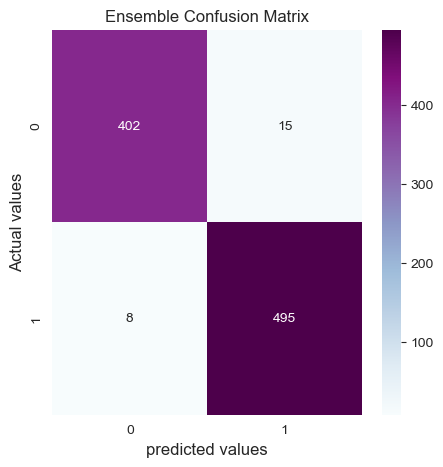

In [38]:
ensemble_confusion_matrix= confusion_matrix(y_test,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True,fmt="d",cmap="BuPu")
plt.xlabel('predicted values',fontsize=12)
plt.ylabel("Actual values",fontsize=12)
plt.title("Ensemble Confusion Matrix",fontsize=12)
plt.show()

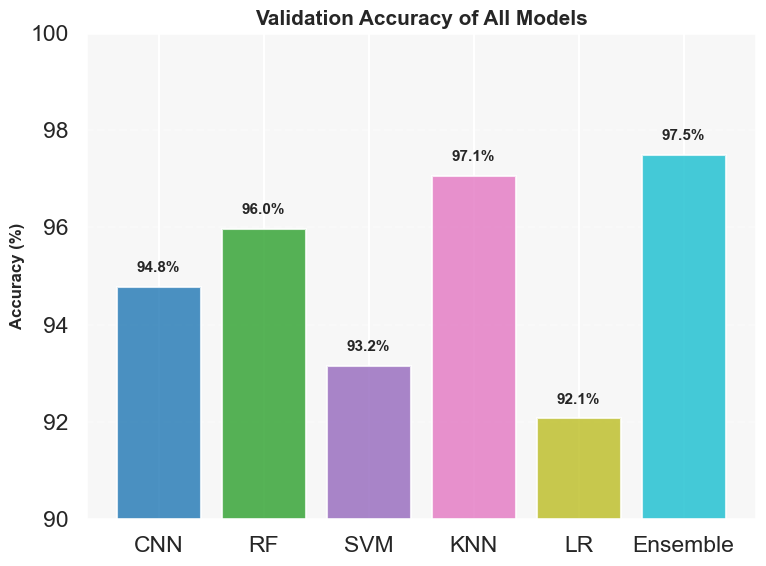

In [39]:
sn.set_style("darkgrid")
sn.set_context("talk")
plt.figure(figsize=(8,6))

colors = plt.get_cmap('tab10', 6)

cnn_acc1 = accuracy_score(y_test, (np.array(pred1))) * 100
rf_acc2  = accuracy_score(y_test, (np.array(pred2))) * 100
svm_acc3 = accuracy_score(y_test, (np.array(pred3))) * 100
knn_acc4 = accuracy_score(y_test, (np.array(pred4))) * 100
lr_acc5  = accuracy_score(y_test, (np.array(pred5))) * 100
ens_acc11  = accuracy_score(y_test, (np.array(Ensemble_prediction))) * 100
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies1 = [cnn_acc1, rf_acc2, svm_acc3, knn_acc4, lr_acc5, ens_acc11]


plt.bar(models, accuracies1, color=[colors(i) for i in range(6)], alpha=0.8)
plt.ylim(90, 100)
plt.ylabel("Accuracy (%)", fontsize=12, weight='bold')
plt.title("Validation Accuracy of All Models", fontsize=15, weight='bold')


for i, v in enumerate(accuracies1):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=11, weight='bold')


plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.tight_layout()
plt.show()


 LOAD UNSEEN IMAGES

In [40]:
img_path = "../data/unseen/"
classes_in_dir = {'(test)Tumor': 1, '(test)Healty': 0}

X, Y = [], []
filenames = []

for cls in classes_in_dir:
    folder = os.path.join(img_path, cls)
    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (200, 200))

        X.append(img)
        Y.append(classes_in_dir[cls])
        filenames.append(file)

x = np.array(X, dtype="float32") / 255.0
y = np.array(Y)

x_cnn  = x.reshape(-1, 200, 200, 1)
x_flat = x.reshape(-1, 200, 200)


In [41]:
unseen_feats   = extract_hybrid_features(x_flat, cnn_model_path)
preds_rf   = rf.predict_proba(scaler_rf_2.transform(pca_rf.transform(unseen_feats)))[:, 1]
preds_svm  = svm.predict_proba(scaler_svm.transform(pca_svm.transform(unseen_feats)))[:, 1]
preds_knn  = knn.predict_proba(scaler_knn.transform(pca_knn.transform(unseen_feats)))[:, 1]
preds_lr   = LogR.predict_proba(scaler_LR.transform(pca_LR.transform(unseen_feats)))[:, 1]
preds_cnn = cnn.predict(x_cnn).flatten()


p_cnn = (preds_cnn >= 0.5).astype(int)
p_rf  = (preds_rf  >= 0.5).astype(int)
p_svm = (preds_svm >= 0.5).astype(int)
p_knn = (preds_knn >= 0.5).astype(int)
p_lr  = (preds_lr  >= 0.5).astype(int)

cnn_acc22 = accuracy_score(y, p_cnn)
rf_acc22  = accuracy_score(y, p_rf)
svm_acc22 = accuracy_score(y, p_svm)
knn_acc22 = accuracy_score(y, p_knn)
lr_acc22  = accuracy_score(y, p_lr)

cnn_acc22= cnn_acc22*100
rf_acc22=rf_acc22*100
svm_acc22 = svm_acc22*100
knn_acc22 = knn_acc22*100
lr_acc22  = lr_acc22*100



preds_stack = np.vstack([preds_cnn, preds_rf, preds_svm, preds_knn, preds_lr]).T

weighted_sum82 = np.dot(preds_stack, weights1)
ensemble_pred = (weighted_sum82 >= 0.5).astype(int)

acc_ensemble = accuracy_score(y, ensemble_pred)
acc_ensemble=acc_ensemble*100

print("\n==============================")
print("ACCURACY SUMMARY of All Models")
print("==============================")

print(f"Total Images     : {len(y)}\n")
print(f"CNN Accuracy     : {cnn_acc22:.2f}%")
print(f"RF Accuracy      : {rf_acc22:.2f}%")
print(f"SVM Accuracy     : {svm_acc22:.2f}%")
print(f"KNN Accuracy     : {knn_acc22:.2f}%")
print(f"LR Accuracy      : {lr_acc22:.2f}%")

print("--------------------------------")
print(f"Ensemble Accuracy: {acc_ensemble:.2f}%")
print("--------------------------------")


print("\n==============================")
print("PER-IMAGE MODEL PREDICTIONS")
print("==============================\n")

for i, file in enumerate(filenames):

    print(
        f"{file:25s} | "
        f"CNN={p_cnn[i]} ({preds_cnn[i]:.3f}) | "
        f"RF={p_rf[i]} ({preds_rf[i]:.3f}) | "
        f"SVM={p_svm[i]} ({preds_svm[i]:.3f}) | "
        f"KNN={p_knn[i]} ({preds_knn[i]:.3f}) | "
        f"LR={p_lr[i]} ({preds_lr[i]:.3f}) | "
        f"Ensemble  = {ensemble_pred[i]}"
    )

print("Classification Report - CNN:")
print(classification_report(y, p_cnn))
print("Classification Report - RF:")
print(classification_report(y, p_rf))
print("Classification Report - SVM:")
print(classification_report(y, p_svm))
print("Classification Report - KNN:")
print(classification_report(y, p_knn))
print("Classification Report - LR:")
print(classification_report(y, p_lr))
print("Classification Report - ENSEMBLE MODELS:")
print(classification_report(y, ensemble_pred))


ACCURACY SUMMARY of All Models
Total Images     : 600

CNN Accuracy     : 91.67%
RF Accuracy      : 90.67%
SVM Accuracy     : 90.83%
KNN Accuracy     : 89.67%
LR Accuracy      : 88.83%
--------------------------------
Ensemble Accuracy: 97.17%
--------------------------------

PER-IMAGE MODEL PREDICTIONS

[Per-image prediction rows omitted from public notebook output.]

Classification Report - CNN:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       300
           1       0.94      0.89      0.91       300

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600

Classification Report - RF:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       300
           1       0.95      0.86      0.90       300

    accuracy                           0.91       600
   macro avg       0.91  


Confusion Matrix:
 [[296   4]
 [ 13 287]]


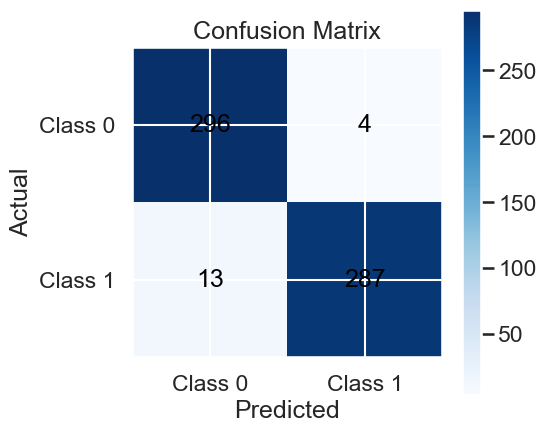

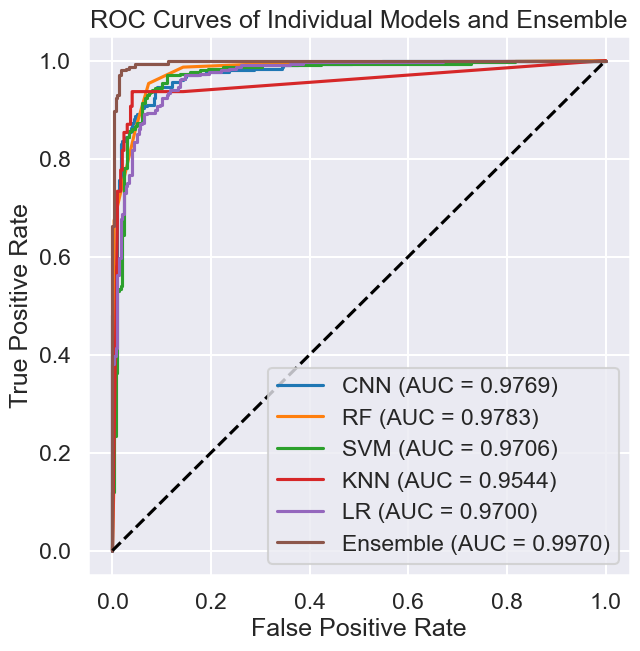

In [42]:

cm = confusion_matrix(y, ensemble_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




models = {
    "CNN": preds_cnn,
    "RF": preds_rf,
    "SVM": preds_svm,
    "KNN": preds_knn,
    "LR":preds_lr,
    "Ensemble": weighted_sum82
}

plt.figure(figsize=(7,7))

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Individual Models and Ensemble")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



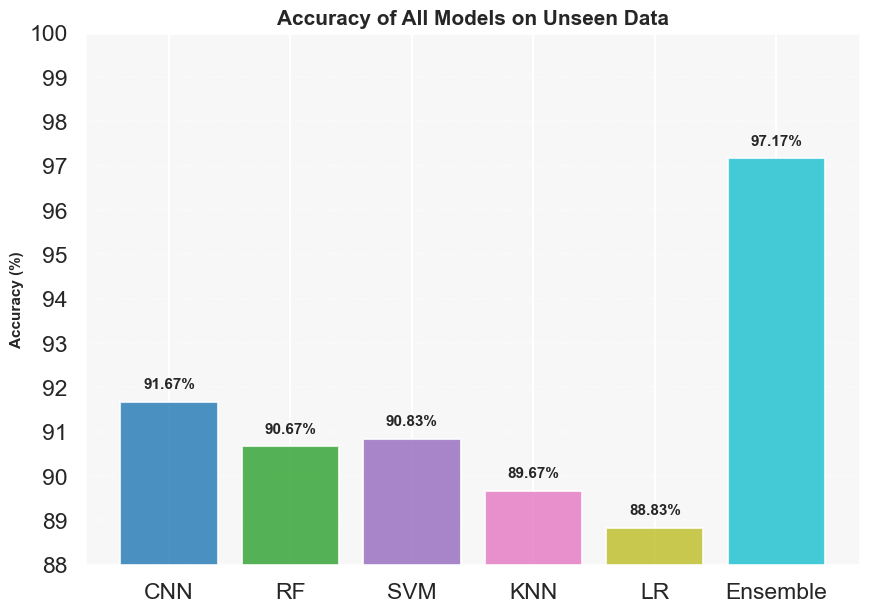

In [43]:
sn.set_style("darkgrid")
sn.set_context("talk")

plt.figure(figsize=(10,7))
colors = plt.get_cmap('tab10', 6)
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies22 = [cnn_acc22, rf_acc22, svm_acc22, knn_acc22, lr_acc22, acc_ensemble]

bars = plt.bar(models, accuracies22, color=[colors(i) for i in range(6)], alpha=0.8)
import numpy as np

plt.ylim(88, 100)
plt.yticks(np.arange(88, 101, 1))


plt.ylabel("Accuracy (%)", fontsize=11, weight='bold')
plt.title("Accuracy of All Models on Unseen Data", fontsize=15, weight='bold')


for bar, acc in zip(bars, accuracies22):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.3, f"{acc:.2f}%", 
             ha='center', fontsize=11, weight='bold') 


plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')


plt.subplots_adjust(top=0.88, bottom=0.12)

plt.show()



Feature Extraction

In [ ]:

def extract_lbp_features(images, P=8, R=1, bins=256):
    feats = []
    
    for img in images:
        img = img.astype(np.uint8)  
        lbp = local_binary_pattern(img, P, R, method="uniform")
        hist, _ = np.histogram(
            lbp.ravel(),
            bins=bins,
            range=(0, bins),
            density=True
        )
        
        feats.append(hist.astype(np.float32))
    
    return np.array(feats, dtype=np.float32)




def extract_hog_feature(images):
    hog_features = []

    for img in images:
        if img.ndim == 3:
            img = rgb2gray(img)
        feat = hog(
            img,
            orientations=4,
            pixels_per_cell=(32, 32),
            cells_per_block=(1, 1),
            block_norm='L1',
            transform_sqrt=False,
            feature_vector=True
        )

        hog_features.append(feat)

    return np.array(hog_features)


def extract_cnn_features(images, cnn_model_path, batch_size=32):

    cnn = load_model(cnn_model_path, compile=False)

    for layer in cnn.layers:
        layer.trainable = False
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer._per_input_updates = {}
            layer._assign_moving_average = lambda *args, **kwargs: None
        if isinstance(layer, tf.keras.layers.Dropout):
            layer.rate = 0.0

    feature_layer = cnn.layers[-3].output
    feature_model = Model(inputs=cnn.input, outputs=feature_layer)

    if images.ndim == 3:
        images = images[..., np.newaxis]

    images = images.astype(np.float32) / 255.0

    feats = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        batch_feat = feature_model(batch, training=False)
        feats.append(batch_feat.numpy().reshape(len(batch_feat), -1))

    return np.vstack(feats).astype(np.float32)




def glcmf(img, levels=32):
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = (img * (levels - 1)).astype(np.uint8)
    glcm = graycomatrix(
        img,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=levels,
        symmetric=True,
        normed=True
    )
    return np.hstack([
        graycoprops(glcm, 'contrast').ravel(),
        graycoprops(glcm, 'correlation').ravel(),
        graycoprops(glcm, 'energy').ravel(),
        graycoprops(glcm, 'homogeneity').ravel()
    ])

def extract_glcm_features(images, levels=32):
    images = np.asarray(images)
    if images.ndim == 2:
        return glcmf(images, levels)

    features = np.zeros((images.shape[0], 16), dtype=np.float32)
    for i, img in enumerate(images):
        features[i] = glcmf(img, levels)
    return features



# ------------------ extract_wavelet_cnn_features ------------------
def extract_wavelet_cnn_features(images, cnn_model_path):
    wave = extract_wavelet_features(images)
    cnnf = extract_cnn_features(images, cnn_model_path)

    n = min(len(wave), len(cnnf))
    hybrid = np.hstack([wave[:n], cnnf[:n]])
    return np.nan_to_num(hybrid).astype(np.float32)


# ------------------ extract_hog_cnn_features ------------------
def extract_hog_cnn_features(images, cnn_model_path):

    hogf = extract_hog_feature(images)  
    cnnf = extract_cnn_features(images, cnn_model_path)

    n = min(len(hogf), len(cnnf))
    hybrid = np.hstack([hogf[:n], cnnf[:n]])

    return np.nan_to_num(hybrid).astype(np.float32)


1) extract_hog_features

In [ ]:

rf1 = RandomForestClassifier(n_estimators=7, random_state=42)
svm1= SVC(C=1e-3, kernel='linear', class_weight="balanced", probability=True, random_state=42)
knn1 = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
lr1 = LogisticRegression( C=0.001, solver="liblinear", penalty="l2",max_iter=2000,class_weight="balanced",random_state=42)

# ------------------------ 1) Random Forest ------------------------
X_train_21 = extract_hog_feature(x_train_rf)
X_test_21  = extract_hog_feature(x_test_ml)
print("extract_hog_features RF train shape:", X_train_21.shape)
print("extract_hog_features RF test shape :", X_test_21.shape)

rf1.fit(X_train_21, y_train_rf)
pred21 = rf1.predict(X_test_21 )
h11= accuracy_score(y_test, pred21)
print("(extract_hog_features) RF Train Accuracy:", rf1.score(X_train_21, y_train_rf))
print("(extract_hog_features) RF Test Accuracy :",h11)
print(classification_report(y_test, pred21))

# ------------------------ 2) Svm ------------------------
X_train_hog_svm = extract_hog_feature(x_train_svm)
X_test_hog_svm  = extract_hog_feature(x_test_ml)
print("HOG SVM train shape:", X_train_hog_svm.shape)
print("HOG SVM test shape :", X_test_hog_svm.shape)

svm1.fit(X_train_hog_svm, y_train_svm)
pred_hog_svm = svm1.predict(X_test_hog_svm)
h12=accuracy_score(y_test, pred_hog_svm)
print("(HOG) SVM Train Accuracy:", svm1.score(X_train_hog_svm, y_train_svm))
print("(HOG) SVM  Test Accuracy :", h12)
print(classification_report(y_test, pred_hog_svm))


# ------------------------ 3) Knn ------------------------
X_train_hog_knn = extract_hog_feature(x_train_rf)
X_test_hog_knn  = extract_hog_feature(x_test_ml)
print("HOG KNN train shape:", X_train_hog_knn.shape)
print("HOG KNN test shape :", X_test_hog_knn.shape)

knn1.fit(X_train_hog_knn, y_train_knn)
pred_hog_knn = knn1.predict(X_test_hog_knn)
h13=accuracy_score(y_test, pred_hog_knn)
print("(HOG) KNN Train Accuracy:", knn1.score(X_train_hog_knn, y_train_knn))
print("(HOG) KNN Test Accuracy :", h13)
print(classification_report(y_test, pred_hog_knn))



# ------------------------ 4) LR ------------------------
X_train_hog_lr = extract_hog_feature(x_train_lr)
X_test_hog_lr  = extract_hog_feature(x_test_ml)
print("HOG LR train shape:", X_train_hog_lr.shape)
print("HOG LR test shape :", X_test_hog_lr.shape)

lr1.fit(X_train_hog_lr, y_train_lr)
pred_hog_lr = lr1.predict(X_test_hog_lr)
h14=accuracy_score(y_test, pred_hog_lr)
print("(HOG) LR Train Accuracy:", lr1.score(X_train_hog_lr, y_train_lr))
print("(HOG)  LR Test Accuracy :", h14)
print(classification_report(y_test, pred_hog_lr))


extract_hog_features RF train shape: (7360, 144)
extract_hog_features RF test shape : (920, 144)
(extract_hog_features) RF Train Accuracy: 0.9976902173913044
(extract_hog_features) RF Test Accuracy : 0.9304347826086956
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       417
           1       0.92      0.95      0.94       503

    accuracy                           0.93       920
   macro avg       0.93      0.93      0.93       920
weighted avg       0.93      0.93      0.93       920

HOG SVM train shape: (7360, 144)
HOG SVM test shape : (920, 144)
(HOG) SVM Train Accuracy: 0.680570652173913
(HOG) SVM  Test Accuracy : 0.6858695652173913
              precision    recall  f1-score   support

           0       0.85      0.37      0.52       417
           1       0.65      0.94      0.77       503

    accuracy                           0.69       920
   macro avg       0.75      0.66      0.64       920
weighted avg       0.74    

 2) extract_cnn_features

In [ ]:
rf2 = RandomForestClassifier(n_estimators=7, random_state=42)
svm2= SVC(C=1e-3, kernel='linear', class_weight="balanced", probability=True, random_state=42)
knn2 = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
lr2 = LogisticRegression( C=0.001, solver="liblinear", penalty="l2",max_iter=2000,class_weight="balanced",random_state=42)


# ------------------------ 1) RF------------------------
X_train_22 = extract_cnn_features(x_train_rf, cnn_model_path)
X_test_22  = extract_cnn_features(x_test_ml, cnn_model_path)
print("RF train shape:", X_train_22.shape)
print("RF test shape :", X_test_22.shape)


rf2.fit(X_train_22, y_train_rf)
pred22 = rf2.predict(X_test_22)
h21=accuracy_score(y_test, pred22)
print("(RF features) Train Accuracy:", rf2.score(X_train_22, y_train_rf))
print("(RFfeatures) Test Accuracy :", h21)
print(classification_report(y_test, pred22))
# ------------------------ 2) Svm------------------------
X_train_cnn_svm = extract_cnn_features(x_train_svm, cnn_model_path)
X_test_cnn_svm  = extract_cnn_features(x_test_ml, cnn_model_path)
print("SVM train shape:", X_train_cnn_svm.shape)
print("SVMtest shape :", X_test_cnn_svm.shape)

svm2.fit(X_train_cnn_svm, y_train_svm)
pred_cnn_svm = svm2.predict(X_test_cnn_svm)
h22=accuracy_score(y_test, pred_cnn_svm)
print("(SVM) Train Accuracy:", svm2.score(X_train_cnn_svm, y_train_svm))
print("(SVM) Test Accuracy :", h22)
print(classification_report(y_test, pred_cnn_svm))


# ------------------------ 3) KNN ------------------------
X_train_cnn_knn = extract_cnn_features(x_train_rf, cnn_model_path)
X_test_cnn_knn  = extract_cnn_features(x_test_ml, cnn_model_path)
print("KNN train shape:", X_train_cnn_knn.shape)
print("KNN test shape :", X_test_cnn_knn.shape)

knn2.fit(X_train_cnn_knn, y_train_knn)
pred_cnn_knn = knn2.predict(X_test_cnn_knn)
h23=accuracy_score(y_test, pred_cnn_knn)
print("(kNN) Train Accuracy:", knn2.score(X_train_cnn_knn, y_train_knn))
print("(kNN) Test Accuracy :",h23 )
print(classification_report(y_test, pred_cnn_knn))
# ------------------------ 4) LR ------------------------
X_train_cnn_lr = extract_cnn_features(x_train_lr, cnn_model_path)
X_test_cnn_lr  = extract_cnn_features(x_test_ml, cnn_model_path)
print("LR train shape:", X_train_cnn_lr.shape)
print("LR test shape :", X_test_cnn_lr.shape)


lr2.fit(X_train_cnn_lr, y_train_lr)
pred_cnn_lr = lr2.predict(X_test_cnn_lr)
h24=accuracy_score(y_test, pred_cnn_lr)
print("(LR) Train Accuracy:", lr2.score(X_train_cnn_lr, y_train_lr))
print("(LR) Test Accuracy :", h24)
print(classification_report(y_test, pred_cnn_lr))

RF train shape: (7360, 16)
RF test shape : (920, 16)
(RF features) Train Accuracy: 0.9870923913043478
(RFfeatures) Test Accuracy : 0.8010869565217391
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       417
           1       0.81      0.84      0.82       503

    accuracy                           0.80       920
   macro avg       0.80      0.80      0.80       920
weighted avg       0.80      0.80      0.80       920

SVM train shape: (7360, 16)
SVMtest shape : (920, 16)
(SVM) Train Accuracy: 0.5461956521739131
(SVM) Test Accuracy : 0.5467391304347826
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       417
           1       0.55      1.00      0.71       503

    accuracy                           0.55       920
   macro avg       0.27      0.50      0.35       920
weighted avg       0.30      0.55      0.39       920



c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


KNN train shape: (7360, 16)
KNN test shape : (920, 16)
(kNN) Train Accuracy: 1.0
(kNN) Test Accuracy : 0.8010869565217391
              precision    recall  f1-score   support

           0       0.74      0.86      0.80       417
           1       0.86      0.76      0.81       503

    accuracy                           0.80       920
   macro avg       0.80      0.81      0.80       920
weighted avg       0.81      0.80      0.80       920

LR train shape: (7360, 16)
LR test shape : (920, 16)
(LR) Train Accuracy: 0.5125
(LR) Test Accuracy : 0.508695652173913
              precision    recall  f1-score   support

           0       0.48      0.93      0.63       417
           1       0.73      0.16      0.27       503

    accuracy                           0.51       920
   macro avg       0.60      0.54      0.45       920
weighted avg       0.61      0.51      0.43       920



3) Wavelet Features

In [ ]:
rf3 = RandomForestClassifier(n_estimators=7, random_state=42)
svm3= SVC(C=1e-3, kernel='linear', class_weight="balanced", probability=True, random_state=42)
knn3 = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
lr3 = LogisticRegression( C=0.001, solver="liblinear", penalty="l2",max_iter=2000,class_weight="balanced",random_state=42)
# ------------------------ 1) RF------------------------
X_train_23 = extract_wavelet_features(x_train_rf)
X_test_23  = extract_wavelet_features(x_test_ml)
print("Wavelet RF train shape:", X_train_23.shape)
print("Wavelet RF test shape :", X_test_23.shape)

rf3.fit(X_train_23, y_train_rf)
pred23 = rf3.predict(X_test_23)
h31=accuracy_score(y_test, pred23)
print("(Wavelet features) RF Train Accuracy:", rf3.score(X_train_23, y_train_rf))
print("(Wavelet features) RF Test Accuracy :", h31)
print(classification_report(y_test, pred23))


# ------------------------ 2) SVM ------------------------
X_train_wave_svm = extract_wavelet_features(x_train_svm)
X_test_wave_svm  = extract_wavelet_features(x_test_ml)
print("Wavelet SVM train shape:", X_train_wave_svm.shape)
print("Wavelet SVM test shape :", X_test_wave_svm.shape)

svm3.fit(X_train_wave_svm, y_train_svm)
pred_wave_svm = svm3.predict(X_test_wave_svm)
h32= accuracy_score(y_test, pred_wave_svm)
print("(Wavelet) SVM Train Accuracy:", svm3.score(X_train_wave_svm, y_train_svm))
print("(Wavelet) SVM Test Accuracy :",h32)
print(classification_report(y_test, pred_wave_svm))

# ------------------------ 3) KNN ------------------------
X_train_wave_knn = extract_wavelet_features(x_train_rf)
X_test_wave_knn  = extract_wavelet_features(x_test_ml)
print("Wavelet KNN train shape:", X_train_wave_knn.shape)
print("Wavelet KNN test shape :", X_test_wave_knn.shape)

knn3.fit(X_train_wave_knn, y_train_knn)
pred_wave_knn = knn3.predict(X_test_wave_knn)
h33= accuracy_score(y_test, pred_wave_knn)
print("(Wavelet) KNN Train Accuracy:", knn3.score(X_train_wave_knn, y_train_knn))
print("(Wavelet) KNN  Test Accuracy :",h33)
print(classification_report(y_test, pred_wave_knn))
# ------------------------ 4) LR ------------------------
X_train_wave_lr = extract_wavelet_features(x_train_lr)
X_test_wave_lr  = extract_wavelet_features(x_test_ml)
print("Wavelet LR train shape:", X_train_wave_lr.shape)
print("Wavelet LR test shape :", X_test_wave_lr.shape)

lr3.fit(X_train_wave_lr, y_train_lr)
pred_wave_lr = lr3.predict(X_test_wave_lr)
h34=accuracy_score(y_test, pred_wave_lr)
print("(Wavelet) LR Train Accuracy:", lr3.score(X_train_wave_lr, y_train_lr))
print("(Wavelet) LR Test Accuracy :", h34)
print(classification_report(y_test, pred_wave_lr))

Wavelet RF train shape: (7360, 5408)
Wavelet RF test shape : (920, 5408)
(Wavelet features) RF Train Accuracy: 0.9979619565217391
(Wavelet features) RF Test Accuracy : 0.9402173913043478
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       417
           1       0.94      0.95      0.95       503

    accuracy                           0.94       920
   macro avg       0.94      0.94      0.94       920
weighted avg       0.94      0.94      0.94       920

Wavelet SVM train shape: (7360, 5408)
Wavelet SVM test shape : (920, 5408)
(Wavelet) SVM Train Accuracy: 0.7358695652173913
(Wavelet) SVM Test Accuracy : 0.8858695652173914
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       417
           1       0.91      0.88      0.89       503

    accuracy                           0.89       920
   macro avg       0.88      0.89      0.89       920
weighted avg       0.89      0.89      0.

4) GLCM features

In [ ]:
rf4 = RandomForestClassifier(n_estimators=7, random_state=42)
svm4= SVC(C=1e-3, kernel='linear', class_weight="balanced", probability=True, random_state=42)
knn4 = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
lr4 = LogisticRegression( C=0.001, solver="liblinear", penalty="l2",max_iter=2000,class_weight="balanced",random_state=42)

# ------------------------ 1) RF ------------------------
X_train_24 = extract_glcm_features(x_train_rf)
X_test_24  = extract_glcm_features(x_test_ml)
print("GLCM features RF train shape:", X_train_24.shape)
print("GLCM features RF test shape :", X_test_24.shape)

rf4.fit(X_train_24, y_train_rf)
pred24 = rf4.predict(X_test_24 )
h41=accuracy_score(y_test, pred24)
print("(GLCM features features) RF Train Accuracy:", rf4.score(X_train_24, y_train_rf))
print("(GLCM features features) RF Test Accuracy :", h41)
print(classification_report(y_test, pred24))


# ------------------------ 2)SVM  ------------------------
X_train_wave_hog_svm = extract_glcm_features(x_train_svm)
X_test_wave_hog_svm  = extract_glcm_features(x_test_ml)
print("GLCM features SVM train shape:", X_train_wave_hog_svm.shape)
print("GLCM features SVM  test shape :", X_test_wave_hog_svm.shape)

svm4.fit(X_train_wave_hog_svm, y_train_svm)
pred_wave_hog_svm = svm4.predict(X_test_wave_hog_svm)
h42= accuracy_score(y_test, pred_wave_hog_svm)
print("(GLCM features) SVM Train Accuracy:", svm4.score(X_train_wave_hog_svm, y_train_svm))
print("(GLCM features) SVM Test Accuracy :",h42)
print(classification_report(y_test, pred_wave_hog_svm))

# ------------------------ 3) KNN------------------------
X_train_wave_hog_knn = extract_glcm_features(x_train_rf)
X_test_wave_hog_knn  = extract_glcm_features(x_test_ml)
print("GLCM features KNN train shape:", X_train_wave_hog_knn.shape)
print("GLCM features KNN test shape :", X_test_wave_hog_knn.shape)

knn4.fit(X_train_wave_hog_knn, y_train_knn)
pred_wave_hog_knn = knn4.predict(X_test_wave_hog_knn)
h43= accuracy_score(y_test, pred_wave_hog_svm)
print("(GLCM features) KNN Train Accuracy:", knn4.score(X_train_wave_hog_knn, y_train_knn))
print("(GLCM features) KNN Test Accuracy :", h43)
print(classification_report(y_test, pred_wave_hog_knn))

# ------------------------ 4) LR ------------------------
X_train_wave_hog_lr = extract_glcm_features(x_train_lr)
X_test_wave_hog_lr  = extract_glcm_features(x_test_ml)
print("GLCM features LR train shape:", X_train_wave_hog_lr.shape)
print("GLCM features LR test shape :", X_test_wave_hog_lr.shape)

lr4.fit(X_train_wave_hog_lr, y_train_lr)
pred_wave_hog_lr = lr4.predict(X_test_wave_hog_lr)
h44=accuracy_score(y_test, pred_wave_hog_lr)
print("(GLCM features) LR Train Accuracy:", lr4.score(X_train_wave_hog_lr, y_train_lr))
print("(GLCM features) LR Test Accuracy :", h44)
print(classification_report(y_test, pred_wave_hog_lr))


GLCM features RF train shape: (7360, 16)
GLCM features RF test shape : (920, 16)
(GLCM features features) RF Train Accuracy: 0.9944293478260869
(GLCM features features) RF Test Accuracy : 0.908695652173913
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       417
           1       0.92      0.91      0.92       503

    accuracy                           0.91       920
   macro avg       0.91      0.91      0.91       920
weighted avg       0.91      0.91      0.91       920

GLCM features SVM train shape: (7360, 16)
GLCM features SVM  test shape : (920, 16)
(GLCM features) SVM Train Accuracy: 0.6677989130434783
(GLCM features) SVM Test Accuracy : 0.675
              precision    recall  f1-score   support

           0       0.67      0.56      0.61       417
           1       0.68      0.77      0.72       503

    accuracy                           0.68       920
   macro avg       0.67      0.66      0.67       920
weighted avg  

5) extract_lbp_features

In [ ]:
rf5 = RandomForestClassifier(n_estimators=7, random_state=42)
svm5= SVC(C=1e-3, kernel='linear', class_weight="balanced", probability=True, random_state=42)
knn5 = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
lr5 = LogisticRegression( C=0.001, solver="liblinear", penalty="l2",max_iter=2000,class_weight="balanced",random_state=42)

# ------------------------ 1)RF ------------------------
X_train_25 = extract_lbp_features(x_train_rf)
X_test_25  = extract_lbp_features(x_test_ml)
print("LBP train RF shape:", X_train_25.shape)
print("LBP test RF shape :", X_test_25.shape)

rf5.fit(X_train_25 , y_train_rf)
pred25 = rf5.predict(X_test_25)
h51=accuracy_score(y_test, pred25)
print("(LBP features) RF Train Accuracy:", rf5.score(X_train_25 , y_train_rf))
print("(LBP features) RF Test Accuracy :", h51)
print(classification_report(y_test, pred25))
# ------------------------ 2) svm ------------------------
X_train_lbp_svm = extract_lbp_features(x_train_svm)
X_test_lbp_svm  = extract_lbp_features(x_test_ml)
print("LBP SVM train shape:", X_train_lbp_svm.shape)
print("LBP SVM test shape :", X_test_lbp_svm.shape)


svm5.fit(X_train_lbp_svm  , y_train_svm)
pred_lbp_svm = svm5.predict(X_test_lbp_svm)
h52=accuracy_score(y_test, pred_lbp_svm)
print("(LBP) SVM Train Accuracy:", svm5.score(X_train_lbp_svm  , y_train_svm))
print("(LBP) SVM Test Accuracy :", h52)
print(classification_report(y_test, pred_lbp_svm))

# ------------------------ 3) KNN ------------------------
X_train_lbp_knn = extract_lbp_features(x_train_rf)
X_test_lbp_knn  = extract_lbp_features(x_test_ml)
print("LBP KNNtrain shape:", X_train_lbp_knn.shape)
print("LBP KNN test shape :", X_test_lbp_knn.shape)

knn5.fit(X_train_lbp_knn, y_train_knn)
pred_lbp_knn = knn5.predict(X_test_lbp_knn)
h53=accuracy_score(y_test, pred_lbp_knn)
print("(LBP) KNN Train Accuracy:", knn5.score(X_train_lbp_knn, y_train_knn))
print("(LBP) KNN Test Accuracy :", h53)
print(classification_report(y_test, pred_lbp_knn))

# ------------------------ 4) LR------------------------
X_train_lbp_lr = extract_lbp_features(x_train_lr)
X_test_lbp_lr  = extract_lbp_features(x_test_ml)
print("LBP LR train shape:", X_train_lbp_lr.shape)
print("LBP LR test shape :", X_test_lbp_lr.shape)




lr5.fit(X_train_lbp_lr , y_train_lr)
pred_lbp_lr = lr5.predict(X_test_lbp_lr )
h54=accuracy_score(y_test, pred_lbp_lr)
print("(LBP) LR Train Accuracy:", lr5.score(X_train_lbp_lr, y_train_lr))
print("(LBP) LR Test Accuracy :", h54)
print(classification_report(y_test, pred_lbp_lr))


LBP train RF shape: (7360, 256)
LBP test RF shape : (920, 256)
(LBP features) RF Train Accuracy: 0.6868206521739131
(LBP features) RF Test Accuracy : 0.6630434782608695
              precision    recall  f1-score   support

           0       0.67      0.50      0.57       417
           1       0.66      0.80      0.72       503

    accuracy                           0.66       920
   macro avg       0.67      0.65      0.65       920
weighted avg       0.66      0.66      0.65       920

LBP SVM train shape: (7360, 256)
LBP SVM test shape : (920, 256)
(LBP) SVM Train Accuracy: 0.5461956521739131
(LBP) SVM Test Accuracy : 0.5467391304347826
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       417
           1       0.55      1.00      0.71       503

    accuracy                           0.55       920
   macro avg       0.27      0.50      0.35       920
weighted avg       0.30      0.55      0.39       920



c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


LBP KNNtrain shape: (7360, 256)
LBP KNN test shape : (920, 256)
(LBP) KNN Train Accuracy: 0.6865489130434783
(LBP) KNN Test Accuracy : 0.65
              precision    recall  f1-score   support

           0       0.66      0.47      0.55       417
           1       0.65      0.80      0.71       503

    accuracy                           0.65       920
   macro avg       0.65      0.64      0.63       920
weighted avg       0.65      0.65      0.64       920

LBP LR train shape: (7360, 256)
LBP LR test shape : (920, 256)
(LBP) LR Train Accuracy: 0.453804347826087
(LBP) LR Test Accuracy : 0.4532608695652174
              precision    recall  f1-score   support

           0       0.45      1.00      0.62       417
           1       0.00      0.00      0.00       503

    accuracy                           0.45       920
   macro avg       0.23      0.50      0.31       920
weighted avg       0.21      0.45      0.28       920



c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


6) Wavelet + CNN Features

In [ ]:
rf6 = RandomForestClassifier(n_estimators=7, random_state=42)
svm6= SVC(C=1e-3, kernel='linear', class_weight="balanced", probability=True, random_state=42)
knn6 = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
lr6 = LogisticRegression( C=0.001, solver="liblinear", penalty="l2",max_iter=2000,class_weight="balanced",random_state=42)
# ------------------------ 1) RF ------------------------
X_train_29 = extract_wavelet_cnn_features(x_train_rf, cnn_model_path)
X_test_29  = extract_wavelet_cnn_features(x_test_ml, cnn_model_path)
print("Wavelet+CNN RF train shape:", X_train_29.shape)
print("Wavelet+CNN RF test shape :", X_test_29.shape)

rf6.fit(X_train_29, y_train_rf)
pred29 = rf6.predict(X_test_29 )
h61=accuracy_score(y_test, pred29)
print("(Wavelet+CNN features) RF Train Accuracy:", rf6.score(X_train_29, y_train_rf))
print("(Wavelet+CNN features) RF Test Accuracy :", h61)
print(classification_report(y_test, pred29))

# ------------------------ 2) SVM ------------------------
X_train_wave_cnn_svm = extract_wavelet_cnn_features(x_train_svm, cnn_model_path)
X_test_wave_cnn_svm  = extract_wavelet_cnn_features(x_test_ml, cnn_model_path)
print("Wavelet+CNN SVM  train shape:", X_train_wave_cnn_svm.shape)
print("Wavelet+CNN SVM  test shape :", X_test_wave_cnn_svm.shape)

svm6.fit(X_train_wave_cnn_svm, y_train_svm)
pred_wave_cnn_svm = svm6.predict(X_test_wave_cnn_svm)
h62=accuracy_score(y_test, pred_wave_cnn_svm)
print("(Wavelet+CNN) SVM Train Accuracy:", svm6.score(X_train_wave_cnn_svm, y_train_svm))
print("(Wavelet+CNN) SVM Test Accuracy :", h62)
print(classification_report(y_test, pred_wave_cnn_svm))

# ------------------------ 3) KNN ------------------------
X_train_wave_cnn_knn = extract_wavelet_cnn_features(x_train_rf, cnn_model_path)
X_test_wave_cnn_knn  = extract_wavelet_cnn_features(x_test_ml, cnn_model_path)

print("Wavelet+CNN KNN train shape:", X_train_wave_cnn_knn.shape)
print("Wavelet+CNN KNN test shape :", X_test_wave_cnn_knn.shape)

knn6.fit(X_train_wave_cnn_knn, y_train_knn)
pred_wave_cnn_knn = knn6.predict(X_test_wave_cnn_knn)
h63=accuracy_score(y_test, pred_wave_cnn_knn)
print("(Wavelet+CNN) KNN Train Accuracy:", knn6.score(X_train_wave_cnn_knn, y_train_knn))
print("(Wavelet+CNN) KNN Test Accuracy :", h63)
print(classification_report(y_test, pred_wave_cnn_knn))

# ------------------------ Lr ------------------------
X_train_wave_cnn_lr = extract_wavelet_cnn_features(x_train_lr, cnn_model_path)
X_test_wave_cnn_lr  = extract_wavelet_cnn_features(x_test_ml, cnn_model_path)
print("Wavelet+CNN LR train shape:", X_train_wave_cnn_lr.shape)
print("Wavelet+CNN LR test shape :", X_test_wave_cnn_lr.shape)

lr6.fit(X_train_wave_cnn_lr, y_train_lr)
pred_wave_cnn_lr = lr6.predict(X_test_wave_cnn_lr)
h64= accuracy_score(y_test, pred_wave_cnn_lr)
print("(Wavelet+CNN) LR Train Accuracy:", lr6.score(X_train_wave_cnn_lr, y_train_lr))
print("(Wavelet+CNN) LR Test Accuracy :",h64)
print(classification_report(y_test, pred_wave_cnn_lr))


Wavelet+CNN RF train shape: (7360, 5424)
Wavelet+CNN RF test shape : (920, 5424)
(Wavelet+CNN features) RF Train Accuracy: 0.997554347826087
(Wavelet+CNN features) RF Test Accuracy : 0.9489130434782609
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       417
           1       0.96      0.95      0.95       503

    accuracy                           0.95       920
   macro avg       0.95      0.95      0.95       920
weighted avg       0.95      0.95      0.95       920

Wavelet+CNN SVM  train shape: (7360, 5424)
Wavelet+CNN SVM  test shape : (920, 5424)
(Wavelet+CNN) SVM Train Accuracy: 0.7358695652173913
(Wavelet+CNN) SVM Test Accuracy : 0.8858695652173914
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       417
           1       0.91      0.88      0.89       503

    accuracy                           0.89       920
   macro avg       0.88      0.89      0.89       920
weighted

7) HOG + CNN Features

In [ ]:
rf7 = RandomForestClassifier(n_estimators=7, random_state=42)
svm7= SVC(C=1e-3, kernel='linear', class_weight="balanced", probability=True, random_state=42)
knn7 = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='manhattan')
lr7 = LogisticRegression( C=0.001, solver="liblinear", penalty="l2",max_iter=2000,class_weight="balanced",random_state=42)

# ------------------------ 1) RF ------------------------
X_train_210 = extract_hog_cnn_features(x_train_rf, cnn_model_path)
X_test_210  = extract_hog_cnn_features(x_test_ml, cnn_model_path)
print("HOG+CNN RF train shape:", X_train_210.shape)
print("HOG+CNN RF test shape :", X_test_210.shape)

rf7.fit(X_train_210 , y_train_rf)
pred210 = rf7.predict(X_test_210)
h71=accuracy_score(y_test, pred210)
print("(HOG+CNN features) RF Train Accuracy:", rf7.score(X_train_210 , y_train_rf))
print("(HOG+CNN features) RF Test Accuracy :", h71)
print(classification_report(y_test, pred210))

# ------------------------ 2) SVM ------------------------
X_train_hog_cnn_svm = extract_hog_cnn_features(x_train_svm, cnn_model_path)
X_test_hog_cnn_svm  = extract_hog_cnn_features(x_test_ml, cnn_model_path)
print("HOG+CNN SVM train shape:", X_train_hog_cnn_svm.shape)
print("HOG+CNN SVM test shape :", X_test_hog_cnn_svm.shape)

svm7.fit(X_train_hog_cnn_svm, y_train_svm)
pred_hog_cnn_svm = svm7.predict(X_test_hog_cnn_svm)
h72=accuracy_score(y_test, pred_hog_cnn_svm)
print("(HOG+CNN) SVM Train Accuracy:", svm7.score(X_train_hog_cnn_svm, y_train_svm))
print("(HOG+CNN) SVM  Test Accuracy :", h72)
print(classification_report(y_test, pred_hog_cnn_svm))
# ------------------------ 3) KNN ------------------------
X_train_hog_cnn_knn = extract_hog_cnn_features(x_train_rf, cnn_model_path)
X_test_hog_cnn_knn  = extract_hog_cnn_features(x_test_ml, cnn_model_path)
print("HOG+CNN KNN train shape:", X_train_hog_cnn_knn.shape)
print("HOG+CNN KNN test shape :", X_test_hog_cnn_knn.shape)

knn7.fit(X_train_hog_cnn_knn, y_train_knn)
pred_hog_cnn_knn = knn7.predict(X_test_hog_cnn_knn)
h73=accuracy_score(y_test, pred_hog_cnn_knn)
print("(HOG+CNN) KNN  Train Accuracy:", knn7.score(X_train_hog_cnn_knn, y_train_knn))
print("(HOG+CNN) KNN  Test Accuracy :", h73)
print(classification_report(y_test, pred_hog_cnn_knn))


# ------------------------ 4) LR ------------------------
X_train_hog_cnn_lr = extract_hog_cnn_features(x_train_lr, cnn_model_path)
X_test_hog_cnn_lr  = extract_hog_cnn_features(x_test_ml, cnn_model_path)
print("HOG+CNN LR train shape:", X_train_hog_cnn_lr.shape)
print("HOG+CNN LR test shape :", X_test_hog_cnn_lr.shape)

lr7.fit(X_train_hog_cnn_lr, y_train_lr)
pred_hog_cnn_lr = lr7.predict(X_test_hog_cnn_lr)
h74=accuracy_score(y_test, pred_hog_cnn_lr)
print("(HOG+CNN) LR Train Accuracy:", lr7.score(X_train_hog_cnn_lr, y_train_lr))
print("(HOG+CNN) LR Test Accuracy :", h74)
print(classification_report(y_test, pred_hog_cnn_lr))


HOG+CNN RF train shape: (7360, 160)
HOG+CNN RF test shape : (920, 160)
(HOG+CNN features) RF Train Accuracy: 0.9985054347826087
(HOG+CNN features) RF Test Accuracy : 0.9282608695652174
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       417
           1       0.92      0.95      0.94       503

    accuracy                           0.93       920
   macro avg       0.93      0.93      0.93       920
weighted avg       0.93      0.93      0.93       920

HOG+CNN SVM train shape: (7360, 160)
HOG+CNN SVM test shape : (920, 160)
(HOG+CNN) SVM Train Accuracy: 0.6816576086956522
(HOG+CNN) SVM  Test Accuracy : 0.6880434782608695
              precision    recall  f1-score   support

           0       0.85      0.38      0.52       417
           1       0.65      0.94      0.77       503

    accuracy                           0.69       920
   macro avg       0.75      0.66      0.65       920
weighted avg       0.74      0.69      0.66 

#prediction for ensemble on validation data

In [ ]:
pp1 = cnn.predict(x_test_cnn).flatten()  

29/29 [==============================] - 3s 66ms/step


In [ ]:
ex_1=extract_hog_feature(x_test_ml)
ex_2=extract_cnn_features(x_test_ml,cnn_model_path)
ex_3=extract_wavelet_features(x_test_ml)
ex_4=extract_glcm_features(x_test_ml)
ex_5=extract_lbp_features(x_test_ml)
ex_6=extract_wavelet_cnn_features(x_test_ml,cnn_model_path)
ex_7=extract_hog_cnn_features(x_test_ml, cnn_model_path)

Random Forest

In [ ]:
pp21 = rf1.predict_proba(ex_1)[:,1]  
pp22 = rf2.predict_proba(ex_2)[:,1]  
pp23 = rf3.predict_proba(ex_3)[:,1]  
pp24 = rf4.predict_proba(ex_4)[:,1]  
pp25 = rf5.predict_proba(ex_5)[:,1]  
pp26 = rf6.predict_proba(ex_6)[:,1]  
pp27 = rf7.predict_proba(ex_7)[:,1] 


SVM

In [ ]:
pp31 = svm1.predict_proba(ex_1)[:,1]
pp32 = svm2.predict_proba(ex_2)[:,1]
pp33 = svm3.predict_proba(ex_3)[:,1]
pp34 = svm4.predict_proba(ex_4)[:,1]
pp35 = svm5.predict_proba(ex_5)[:,1]
pp36 = svm6.predict_proba(ex_6)[:,1]
pp37 = svm7.predict_proba(ex_7)[:,1]

KNN

In [ ]:
pp41 = knn1.predict_proba(ex_1)[:,1]
pp42 = knn2.predict_proba(ex_2)[:,1]
pp43 = knn3.predict_proba(ex_3)[:,1]
pp44 = knn4.predict_proba(ex_4)[:,1]
pp45 = knn5.predict_proba(ex_5)[:,1]
pp46 = knn6.predict_proba(ex_6)[:,1]
pp47 = knn7.predict_proba(ex_7)[:,1]

LR

In [ ]:
pp51 = lr1.predict_proba(ex_1)[:,1]     
pp52 = lr2.predict_proba(ex_2)[:,1]     
pp53 = lr3.predict_proba(ex_3)[:,1]     
pp54 = lr4.predict_proba(ex_4)[:,1]      
pp55 = lr5.predict_proba(ex_5)[:,1]     
pp56 = lr6.predict_proba(ex_6)[:,1]      
pp57 = lr7.predict_proba(ex_7)[:,1]  

hog_feature below

CNN=0.948  RF=0.930  SVM=0.686  KNN=0.970  LR=0.735

Weights used for soft voting: [0.22205246 0.2179781  0.16068245 0.2271454  0.17214158]
Preds shape: (920, 5)
weighted_sum shape: (920,)

Weighted Soft Voting Ensemble Accuracy: 0.9706521739130435

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       417
           1       0.96      0.99      0.97       503

    accuracy                           0.97       920
   macro avg       0.97      0.97      0.97       920
weighted avg       0.97      0.97      0.97       920


Confusion Matrix:
 [[396  21]
 [  6 497]]


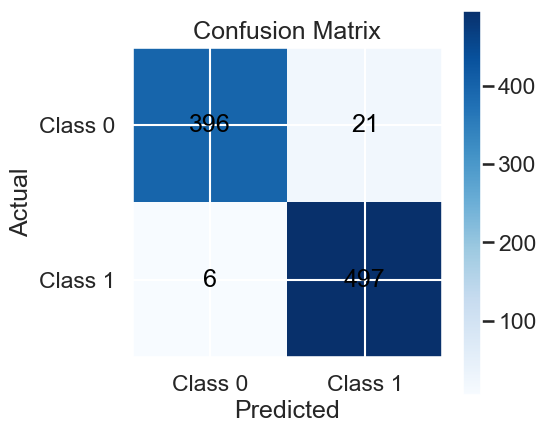

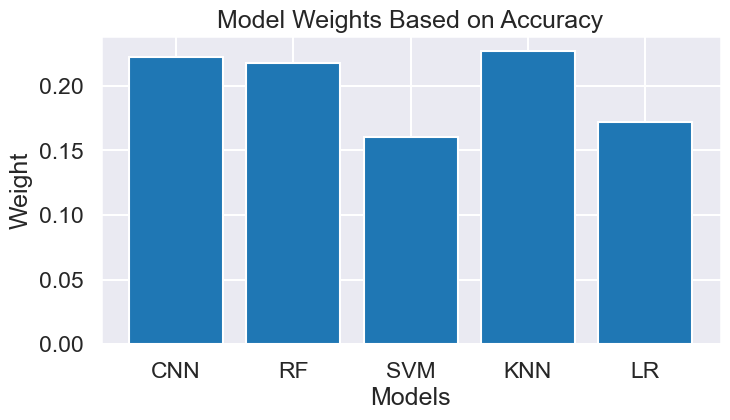


Ensemble Validation Data  AUC Score: 0.9967294554018812


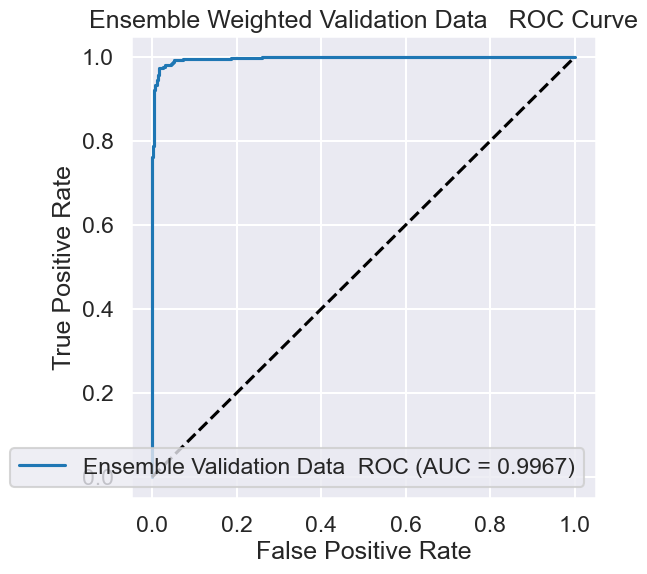

In [ ]:
print(f"CNN={cnn_acc:.3f}  RF={h11:.3f}  SVM={h12:.3f}  KNN={h13:.3f}  LR={h14:.3f}")

accuracies = np.array([cnn_acc,h11, h12, h13, h14], dtype=float)

if accuracies.sum() == 0:
    accuracies = np.ones_like(accuracies)

weights11 = accuracies / accuracies.sum()
print("\nWeights used for soft voting:", weights11)

preds = np.vstack([pp1, pp21, pp31, pp41, pp51]).T
print("Preds shape:", preds.shape)       

weighted_sum1 = np.dot(preds, weights11)
print("weighted_sum shape:", weighted_sum1.shape)   

Ensemble_prediction = (weighted_sum1 >= 0.5).astype(int)

ens_acc = accuracy_score(y_test, Ensemble_prediction)
print("\nWeighted Soft Voting Ensemble Accuracy:", ens_acc)

print("\nClassification Report:")
print(classification_report(y_test, Ensemble_prediction))


cm = confusion_matrix(y_test, Ensemble_prediction)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

labels = ["CNN","RF","SVM","KNN","LR"]

plt.figure(figsize=(8,4))
plt.bar(labels, weights11)
plt.title("Model Weights Based on Accuracy")
plt.ylabel("Weight")
plt.xlabel("Models")
plt.show()


ensemble_probs = weighted_sum1   

fpr, tpr, thresholds = roc_curve(y_test, ensemble_probs)
roc_auc11 = auc(fpr, tpr)

print("\nEnsemble Validation Data  AUC Score:", roc_auc11)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble Validation Data  ROC (AUC = {roc_auc11:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Validation Data   ROC Curve')
plt.legend(loc="lower right")
plt.show()


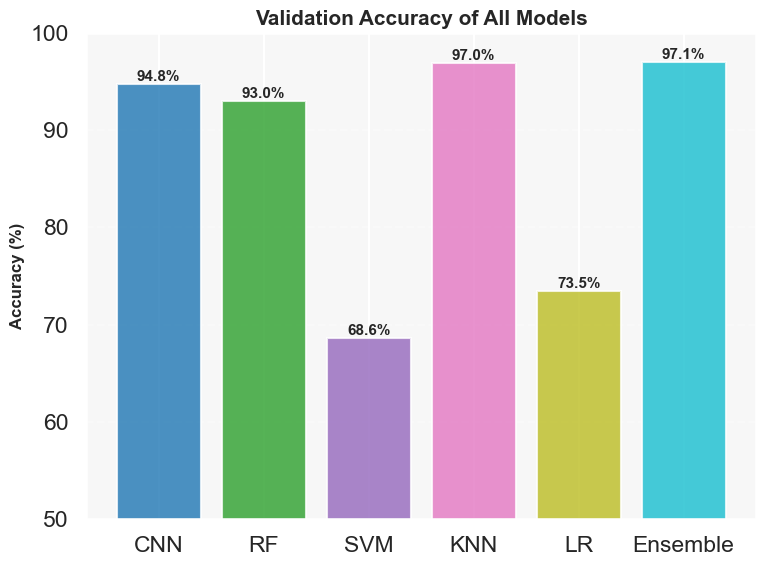

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")
plt.figure(figsize=(8,6))

colors = plt.get_cmap('tab10', 6)
cnn_acc1 = accuracy_score(y_test, (np.array(pred1))) * 100
rf_acc2  = accuracy_score(y_test, (np.array(pred21))) * 100
svm_acc3 = accuracy_score(y_test, (np.array(pred_hog_svm ))) * 100
knn_acc4 = accuracy_score(y_test, (np.array(pred_hog_knn ))) * 100
lr_acc5  = accuracy_score(y_test, (np.array(pred_hog_lr ))) * 100
ens_acc11  = accuracy_score(y_test, (np.array(Ensemble_prediction))) * 100
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies1 = [cnn_acc1, rf_acc2, svm_acc3, knn_acc4, lr_acc5, ens_acc11]

plt.bar(models, accuracies1, color=[colors(i) for i in range(6)], alpha=0.8)
plt.ylim(50, 100)
plt.ylabel("Accuracy (%)", fontsize=12, weight='bold')
plt.title("Validation Accuracy of All Models", fontsize=15, weight='bold')

for i, v in enumerate(accuracies1):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=11, weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.tight_layout()
plt.show()


In [ ]:
unseen_feats   = extract_hog_feature(x_flat)
preds_rf   = rf1.predict_proba(unseen_feats)[:, 1]
preds_svm  = svm1.predict_proba(unseen_feats)[:, 1]
preds_knn  = knn1.predict_proba(unseen_feats)[:, 1]
preds_lr   = lr1.predict_proba(unseen_feats)[:, 1]
preds_cnn = cnn.predict(x_cnn).flatten()


p_cnn = (preds_cnn >= 0.5).astype(int)
p_rf  = (preds_rf  >= 0.5).astype(int)
p_svm = (preds_svm >= 0.5).astype(int)
p_knn = (preds_knn >= 0.5).astype(int)
p_lr  = (preds_lr  >= 0.5).astype(int)

cnn_acc22 = accuracy_score(y, p_cnn)
rf_acc22  = accuracy_score(y, p_rf)
svm_acc22 = accuracy_score(y, p_svm)
knn_acc22 = accuracy_score(y, p_knn)
lr_acc22  = accuracy_score(y, p_lr)

cnn_acc22= cnn_acc22*100
rf_acc22=rf_acc22*100
svm_acc22 = svm_acc22*100
knn_acc22 = knn_acc22*100
lr_acc22  = lr_acc22*100



preds_stack = np.vstack([preds_cnn, preds_rf, preds_svm, preds_knn, preds_lr]).T

weighted_sum12 = np.dot(preds_stack, weights11)
ensemble_pred = (weighted_sum12 >= 0.5).astype(int)

acc_ensemble = accuracy_score(y, ensemble_pred)
acc_ensemble=acc_ensemble*100

print("\n==============================")
print("ACCURACY SUMMARY of All Models")
print("==============================")

print(f"Total Images     : {len(y)}\n")
print(f"CNN Accuracy     : {cnn_acc22:.2f}%")
print(f"RF Accuracy      : {rf_acc22:.2f}%")
print(f"SVM Accuracy     : {svm_acc22:.2f}%")
print(f"KNN Accuracy     : {knn_acc22:.2f}%")
print(f"LR Accuracy      : {lr_acc22:.2f}%")

print("--------------------------------")
print(f"Ensemble Accuracy: {acc_ensemble:.2f}%")
print("--------------------------------")


print("\n==============================")
print("PER-IMAGE MODEL PREDICTIONS")
print("==============================\n")

for i, file in enumerate(filenames):

   ''' print(
        f"{file:25s} | "
        f"CNN={p_cnn[i]} ({preds_cnn[i]:.3f}) | "
        f"RF={p_rf[i]} ({preds_rf[i]:.3f}) | "
        f"SVM={p_svm[i]} ({preds_svm[i]:.3f}) | "
        f"KNN={p_knn[i]} ({preds_knn[i]:.3f}) | "
        f"LR={p_lr[i]} ({preds_lr[i]:.3f}) | "
        f"Ensemble  = {ensemble_pred[i]}" 
    )
'''

print("Classification Report - CNN:")
print(classification_report(y, p_cnn))
print("Classification Report - RF:")
print(classification_report(y, p_rf))
print("Classification Report - SVM:")
print(classification_report(y, p_svm))
print("Classification Report - KNN:")
print(classification_report(y, p_knn))
print("Classification Report - LR:")
print(classification_report(y, p_lr))
print("Classification Report - ENSEMBLE MODELS:")
print(classification_report(y, ensemble_pred))


19/19 [==============================] - 1s 63ms/step

ACCURACY SUMMARY of All Models
Total Images     : 600

CNN Accuracy     : 91.67%
RF Accuracy      : 94.50%
SVM Accuracy     : 66.17%
KNN Accuracy     : 85.17%
LR Accuracy      : 67.00%
--------------------------------
Ensemble Accuracy: 94.83%
--------------------------------

PER-IMAGE MODEL PREDICTIONS

Classification Report - CNN:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       300
           1       0.94      0.89      0.91       300

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600

Classification Report - RF:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       300
           1       0.97      0.92      0.94       300

    accuracy                           0.94       600
   macro avg       0.95      0.95   

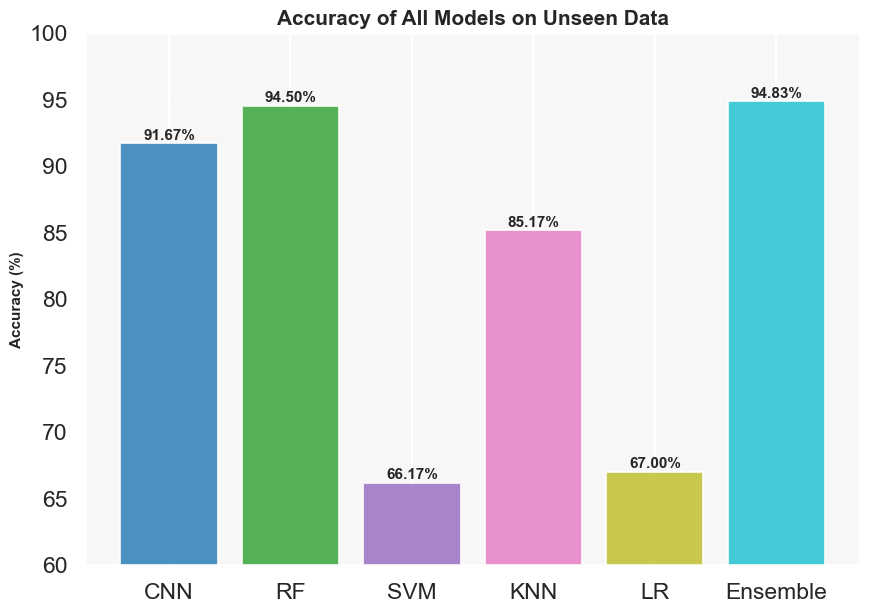

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")

plt.figure(figsize=(10,7))
colors = plt.get_cmap('tab10', 6)
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies22 = [cnn_acc22, rf_acc22, svm_acc22, knn_acc22, lr_acc22, acc_ensemble]

bars = plt.bar(models, accuracies22, color=[colors(i) for i in range(6)], alpha=0.8)
import numpy as np

plt.ylim(60, 100)
plt.ylabel("Accuracy (%)", fontsize=11, weight='bold')
plt.title("Accuracy of All Models on Unseen Data", fontsize=15, weight='bold')

for bar, acc in zip(bars, accuracies22):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.3, f"{acc:.2f}%", 
             ha='center', fontsize=11, weight='bold') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.subplots_adjust(top=0.88, bottom=0.12)

plt.show()




Ensemble Unseen Data  AUC Score: 0.9914777777777778


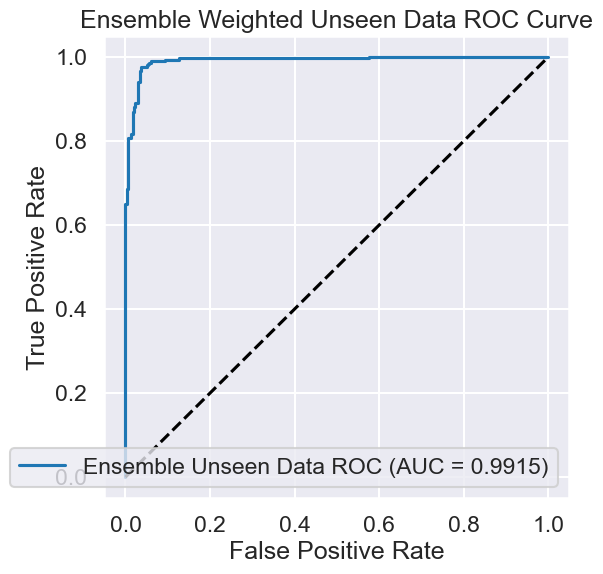

In [ ]:
ensemble_probs = weighted_sum12 

fpr, tpr, thresholds = roc_curve(y, ensemble_probs)
roc_auc12 = auc(fpr, tpr)

print("\nEnsemble Unseen Data  AUC Score:", roc_auc12)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble Unseen Data ROC (AUC = {roc_auc12:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Unseen Data ROC Curve')
plt.legend(loc="lower right")
plt.show()


cnn_features below

CNN=0.948  RF=0.801  SVM=0.547  KNN=0.801  LR=0.509

Weights used for soft voting: [0.26288815 0.22218872 0.15164305 0.22218872 0.14109135]
Preds shape: (920, 5)
weighted_sum shape: (920,)

Weighted Soft Voting Ensemble Accuracy: 0.9184782608695652

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       417
           1       0.92      0.93      0.93       503

    accuracy                           0.92       920
   macro avg       0.92      0.92      0.92       920
weighted avg       0.92      0.92      0.92       920


Confusion Matrix:
 [[378  39]
 [ 36 467]]


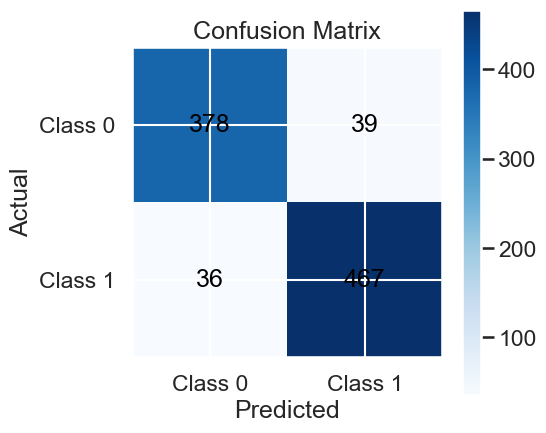

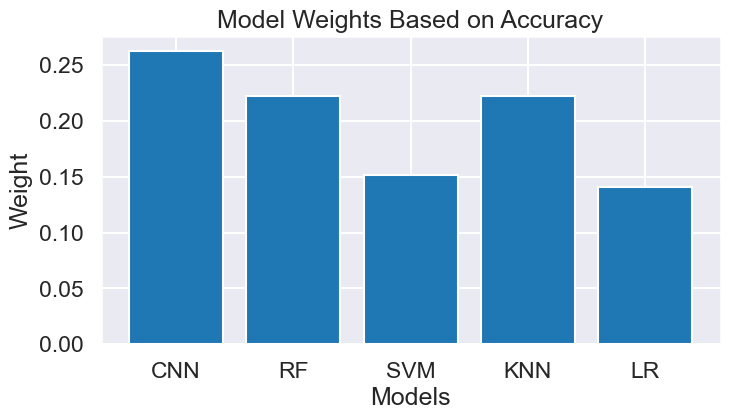


Ensemble  Validation Data  AUC Score: 0.9729059694590253


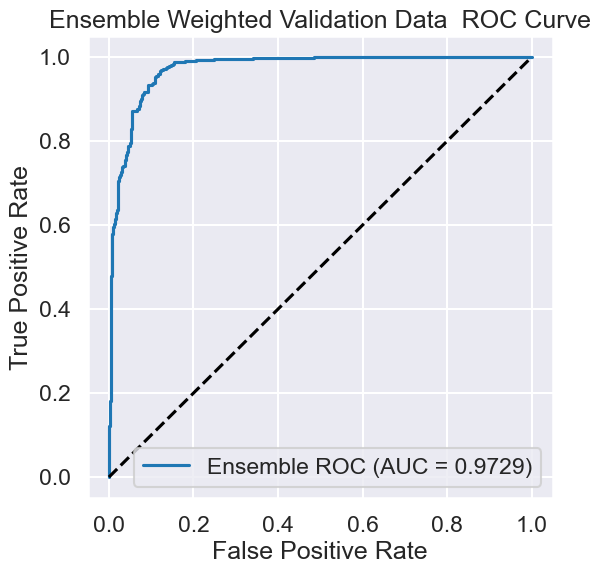

In [ ]:
print(f"CNN={cnn_acc:.3f}  RF={h21:.3f}  SVM={h22:.3f}  KNN={h23:.3f}  LR={h24:.3f}")

accuracies = np.array([cnn_acc,h21, h22, h23, h24], dtype=float)


if accuracies.sum() == 0:
    accuracies = np.ones_like(accuracies)


weights11 = accuracies / accuracies.sum()
print("\nWeights used for soft voting:", weights11)

preds = np.vstack([pp1, pp22, pp32, pp42, pp52]).T
print("Preds shape:", preds.shape)      

weighted_sum21 = np.dot(preds, weights11)
print("weighted_sum shape:", weighted_sum21.shape)  


Ensemble_prediction = (weighted_sum21 >= 0.5).astype(int)

ens_acc = accuracy_score(y_test, Ensemble_prediction)
print("\nWeighted Soft Voting Ensemble Accuracy:", ens_acc)


print("\nClassification Report:")
print(classification_report(y_test, Ensemble_prediction))


cm = confusion_matrix(y_test, Ensemble_prediction)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


labels = ["CNN","RF","SVM","KNN","LR"]

plt.figure(figsize=(8,4))
plt.bar(labels, weights11)
plt.title("Model Weights Based on Accuracy")
plt.ylabel("Weight")
plt.xlabel("Models")
plt.show()


ensemble_probs = weighted_sum21   

fpr, tpr, thresholds = roc_curve(y_test, ensemble_probs)
roc_auc21 = auc(fpr, tpr)

print("\nEnsemble  Validation Data  AUC Score:", roc_auc21)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc21:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Validation Data  ROC Curve')
plt.legend(loc="lower right")
plt.show()


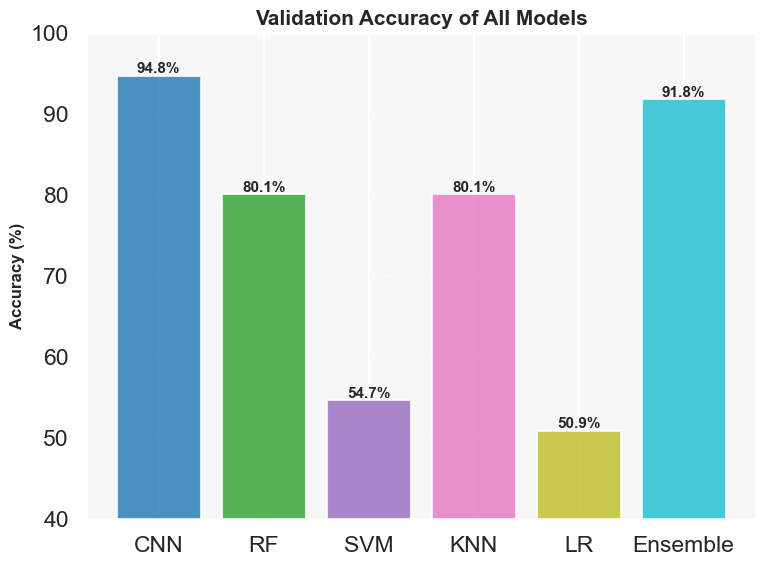

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")
plt.figure(figsize=(8,6))

colors = plt.get_cmap('tab10', 6)

cnn_acc1 = accuracy_score(y_test, (np.array(pred1))) * 100
rf_acc2  = accuracy_score(y_test, (np.array(pred22))) * 100
svm_acc3 = accuracy_score(y_test, (np.array(pred_cnn_svm ))) * 100
knn_acc4 = accuracy_score(y_test, (np.array(pred_cnn_knn ))) * 100
lr_acc5  = accuracy_score(y_test, (np.array(pred_cnn_lr ))) * 100
ens_acc11  = accuracy_score(y_test, (np.array(Ensemble_prediction))) * 100
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies1 = [cnn_acc1, rf_acc2, svm_acc3, knn_acc4, lr_acc5, ens_acc11]

plt.bar(models, accuracies1, color=[colors(i) for i in range(6)], alpha=0.8)
plt.ylim(40, 100)
plt.ylabel("Accuracy (%)", fontsize=12, weight='bold')
plt.title("Validation Accuracy of All Models", fontsize=15, weight='bold')

for i, v in enumerate(accuracies1):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=11, weight='bold')

# Style
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.tight_layout()
plt.show()


In [ ]:
unseen_feats   = extract_cnn_features(x_flat,cnn_model_path)
preds_rf   = rf2.predict_proba(unseen_feats)[:, 1]
preds_svm  = svm2.predict_proba(unseen_feats)[:, 1]
preds_knn  = knn2.predict_proba(unseen_feats)[:, 1]
preds_lr   = lr2.predict_proba(unseen_feats)[:, 1]
preds_cnn = cnn.predict(x_cnn).flatten()


p_cnn = (preds_cnn >= 0.5).astype(int)
p_rf  = (preds_rf  >= 0.5).astype(int)
p_svm = (preds_svm >= 0.5).astype(int)
p_knn = (preds_knn >= 0.5).astype(int)
p_lr  = (preds_lr  >= 0.5).astype(int)

cnn_acc22 = accuracy_score(y, p_cnn)
rf_acc22  = accuracy_score(y, p_rf)
svm_acc22 = accuracy_score(y, p_svm)
knn_acc22 = accuracy_score(y, p_knn)
lr_acc22  = accuracy_score(y, p_lr)

cnn_acc22= cnn_acc22*100
rf_acc22=rf_acc22*100
svm_acc22 = svm_acc22*100
knn_acc22 = knn_acc22*100
lr_acc22  = lr_acc22*100



preds_stack = np.vstack([preds_cnn, preds_rf, preds_svm, preds_knn, preds_lr]).T

weighted_sum22 = np.dot(preds_stack, weights11)
ensemble_pred = (weighted_sum22 >= 0.5).astype(int)

acc_ensemble = accuracy_score(y, ensemble_pred)
acc_ensemble=acc_ensemble*100

print("\n==============================")
print("ACCURACY SUMMARY of All Models")
print("==============================")

print(f"Total Images     : {len(y)}\n")
print(f"CNN Accuracy     : {cnn_acc22:.2f}%")
print(f"RF Accuracy      : {rf_acc22:.2f}%")
print(f"SVM Accuracy     : {svm_acc22:.2f}%")
print(f"KNN Accuracy     : {knn_acc22:.2f}%")
print(f"LR Accuracy      : {lr_acc22:.2f}%")

print("--------------------------------")
print(f"Ensemble Accuracy: {acc_ensemble:.2f}%")
print("--------------------------------")


print("\n==============================")
print("PER-IMAGE MODEL PREDICTIONS")
print("==============================\n")

for i, file in enumerate(filenames):

   ''' print(
        f"{file:25s} | "
        f"CNN={p_cnn[i]} ({preds_cnn[i]:.3f}) | "
        f"RF={p_rf[i]} ({preds_rf[i]:.3f}) | "
        f"SVM={p_svm[i]} ({preds_svm[i]:.3f}) | "
        f"KNN={p_knn[i]} ({preds_knn[i]:.3f}) | "
        f"LR={p_lr[i]} ({preds_lr[i]:.3f}) | "
        f"Ensemble  = {ensemble_pred[i]}" 
    )
'''

print("Classification Report - CNN:")
print(classification_report(y, p_cnn))
print("Classification Report - RF:")
print(classification_report(y, p_rf))
print("Classification Report - SVM:")
print(classification_report(y, p_svm))
print("Classification Report - KNN:")
print(classification_report(y, p_knn))
print("Classification Report - LR:")
print(classification_report(y, p_lr))
print("Classification Report - ENSEMBLE MODELS:")
print(classification_report(y, ensemble_pred))

19/19 [==============================] - 1s 51ms/step

ACCURACY SUMMARY of All Models
Total Images     : 600

CNN Accuracy     : 91.67%
RF Accuracy      : 85.17%
SVM Accuracy     : 50.00%
KNN Accuracy     : 84.50%
LR Accuracy      : 49.67%
--------------------------------
Ensemble Accuracy: 94.33%
--------------------------------

PER-IMAGE MODEL PREDICTIONS

Classification Report - CNN:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       300
           1       0.94      0.89      0.91       300

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600

Classification Report - RF:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       300
           1       0.88      0.81      0.85       300

    accuracy                           0.85       600
   macro avg       0.85      0.85   

c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


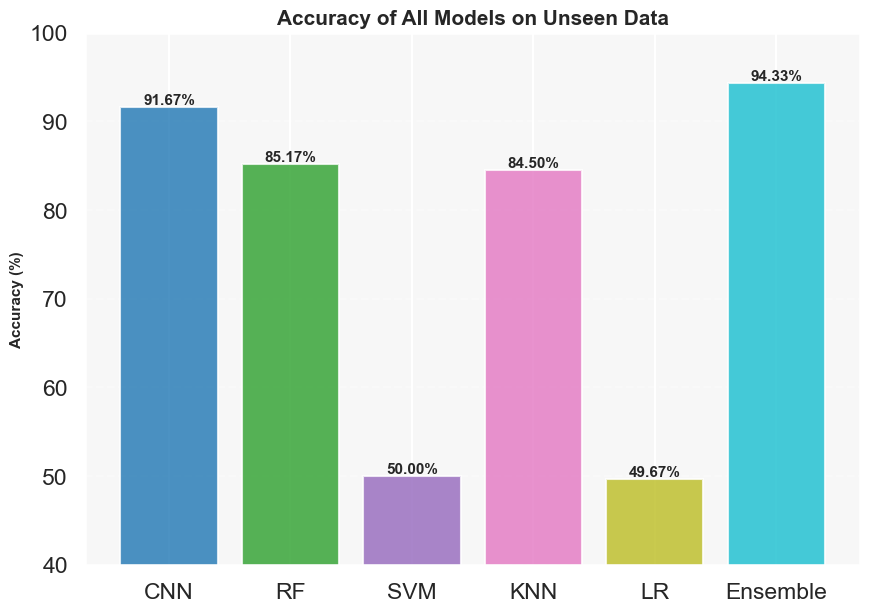

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")


plt.figure(figsize=(10,7))
colors = plt.get_cmap('tab10', 6)
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies22 = [cnn_acc22, rf_acc22, svm_acc22, knn_acc22, lr_acc22, acc_ensemble]

bars = plt.bar(models, accuracies22, color=[colors(i) for i in range(6)], alpha=0.8)
import numpy as np

plt.ylim(40, 100)
plt.ylabel("Accuracy (%)", fontsize=11, weight='bold')
plt.title("Accuracy of All Models on Unseen Data", fontsize=15, weight='bold')

for bar, acc in zip(bars, accuracies22):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.3, f"{acc:.2f}%", 
             ha='center', fontsize=11, weight='bold') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.subplots_adjust(top=0.88, bottom=0.12)

plt.show()




Ensemble Unseen AUC Score: 0.9812555555555555


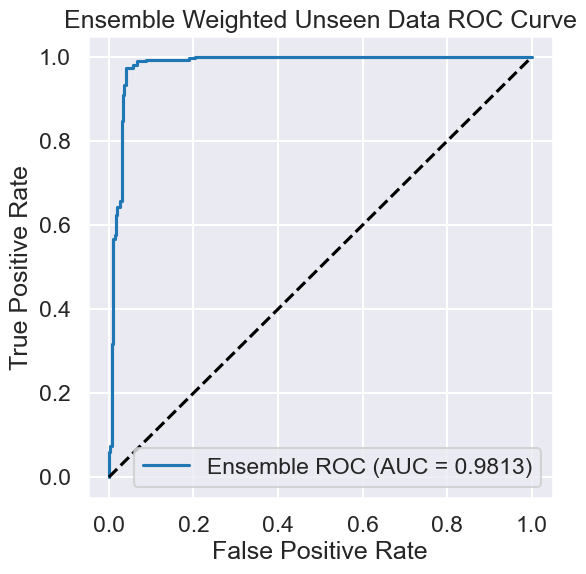

In [ ]:
ensemble_probs = weighted_sum22 

fpr, tpr, thresholds = roc_curve(y, ensemble_probs)
roc_auc22 = auc(fpr, tpr)

print("\nEnsemble Unseen AUC Score:", roc_auc22)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc22:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Unseen Data ROC Curve')
plt.legend(loc="lower right")
plt.show()


wavelet_features below

CNN=0.948  RF=0.940  SVM=0.886  KNN=0.972  LR=0.877

Weights used for soft voting: [0.20503174 0.20338585 0.19162944 0.21020456 0.18974841]
Preds shape: (920, 5)
weighted_sum shape: (920,)

Weighted Soft Voting Ensemble Accuracy: 0.9739130434782609

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       417
           1       0.97      0.98      0.98       503

    accuracy                           0.97       920
   macro avg       0.97      0.97      0.97       920
weighted avg       0.97      0.97      0.97       920


Confusion Matrix:
 [[403  14]
 [ 10 493]]


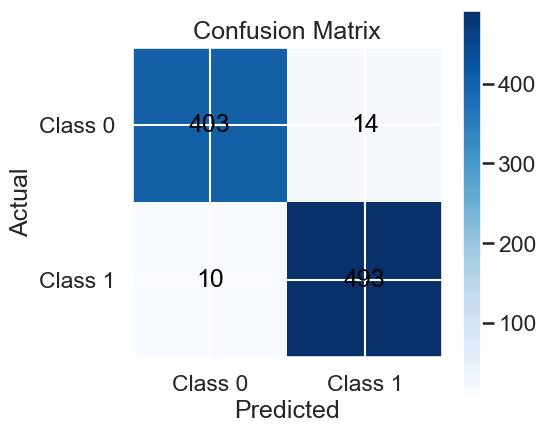

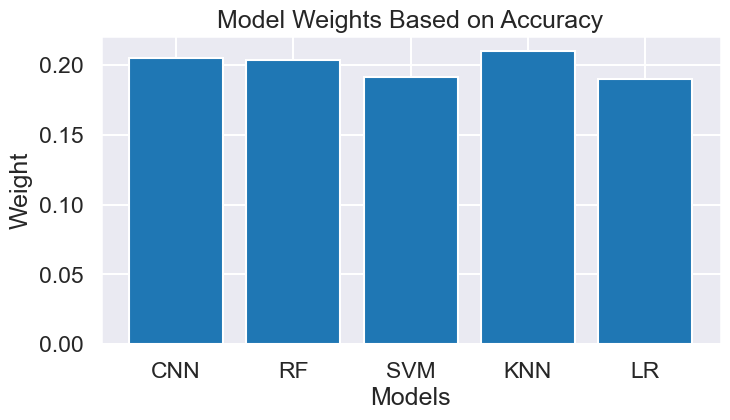


Ensemble Validation Data  AUC Score: 0.9955757064328656


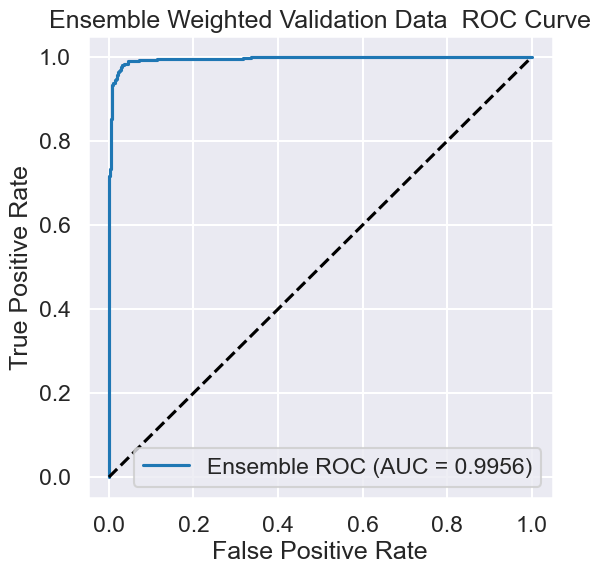

In [ ]:
print(f"CNN={cnn_acc:.3f}  RF={h31:.3f}  SVM={h32:.3f}  KNN={h33:.3f}  LR={h34:.3f}")

accuracies = np.array([cnn_acc,h31, h32, h33, h34], dtype=float)

if accuracies.sum() == 0:
    accuracies = np.ones_like(accuracies)

weights11 = accuracies / accuracies.sum()
print("\nWeights used for soft voting:", weights11)

preds = np.vstack([pp1, pp23, pp33, pp43, pp53]).T
print("Preds shape:", preds.shape)      

weighted_sum31 = np.dot(preds, weights11)
print("weighted_sum shape:", weighted_sum31.shape)  

Ensemble_prediction = (weighted_sum31 >= 0.5).astype(int)

ens_acc = accuracy_score(y_test, Ensemble_prediction)
print("\nWeighted Soft Voting Ensemble Accuracy:", ens_acc)

print("\nClassification Report:")
print(classification_report(y_test, Ensemble_prediction))

cm = confusion_matrix(y_test, Ensemble_prediction)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

labels = ["CNN","RF","SVM","KNN","LR"]

plt.figure(figsize=(8,4))
plt.bar(labels, weights11)
plt.title("Model Weights Based on Accuracy")
plt.ylabel("Weight")
plt.xlabel("Models")
plt.show()

ensemble_probs = weighted_sum31   

fpr, tpr, thresholds = roc_curve(y_test, ensemble_probs)
roc_auc31 = auc(fpr, tpr)

print("\nEnsemble Validation Data  AUC Score:", roc_auc31)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc31:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Validation Data  ROC Curve')
plt.legend(loc="lower right")
plt.show()


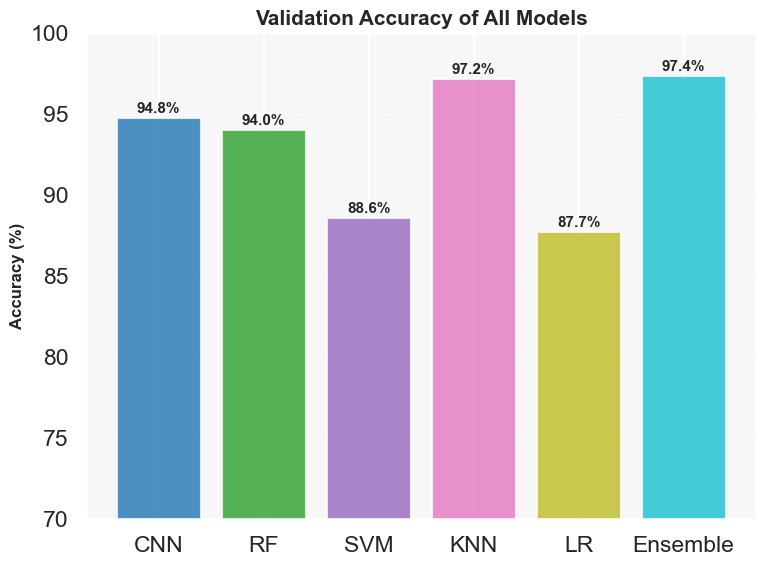

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")
plt.figure(figsize=(8,6))

colors = plt.get_cmap('tab10', 6)
cnn_acc1 = accuracy_score(y_test, (np.array(pred1))) * 100
rf_acc2  = accuracy_score(y_test, (np.array(pred23))) * 100
svm_acc3 = accuracy_score(y_test, (np.array(pred_wave_svm ))) * 100
knn_acc4 = accuracy_score(y_test, (np.array(pred_wave_knn ))) * 100
lr_acc5  = accuracy_score(y_test, (np.array(pred_wave_lr ))) * 100
ens_acc11  = accuracy_score(y_test, (np.array(Ensemble_prediction))) * 100
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies1 = [cnn_acc1, rf_acc2, svm_acc3, knn_acc4, lr_acc5, ens_acc11]

plt.bar(models, accuracies1, color=[colors(i) for i in range(6)], alpha=0.8)
plt.ylim(70, 100)
plt.ylabel("Accuracy (%)", fontsize=12, weight='bold')
plt.title("Validation Accuracy of All Models", fontsize=15, weight='bold')

for i, v in enumerate(accuracies1):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=11, weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.tight_layout()
plt.show()


In [ ]:
unseen_feats   = extract_wavelet_features(x_flat)
preds_rf   = rf3.predict_proba(unseen_feats)[:, 1]
preds_svm  = svm3.predict_proba(unseen_feats)[:, 1]
preds_knn  = knn3.predict_proba(unseen_feats)[:, 1]
preds_lr   = lr3.predict_proba(unseen_feats)[:, 1]
preds_cnn = cnn.predict(x_cnn).flatten()


p_cnn = (preds_cnn >= 0.5).astype(int)
p_rf  = (preds_rf  >= 0.5).astype(int)
p_svm = (preds_svm >= 0.5).astype(int)
p_knn = (preds_knn >= 0.5).astype(int)
p_lr  = (preds_lr  >= 0.5).astype(int)

cnn_acc22 = accuracy_score(y, p_cnn)
rf_acc22  = accuracy_score(y, p_rf)
svm_acc22 = accuracy_score(y, p_svm)
knn_acc22 = accuracy_score(y, p_knn)
lr_acc22  = accuracy_score(y, p_lr)

cnn_acc22= cnn_acc22*100
rf_acc22=rf_acc22*100
svm_acc22 = svm_acc22*100
knn_acc22 = knn_acc22*100
lr_acc22  = lr_acc22*100



preds_stack = np.vstack([preds_cnn, preds_rf, preds_svm, preds_knn, preds_lr]).T

weighted_sum32 = np.dot(preds_stack, weights11)
ensemble_pred = (weighted_sum32 >= 0.5).astype(int)

acc_ensemble = accuracy_score(y, ensemble_pred)
acc_ensemble=acc_ensemble*100

print("\n==============================")
print("ACCURACY SUMMARY of All Models")
print("==============================")

print(f"Total Images     : {len(y)}\n")
print(f"CNN Accuracy     : {cnn_acc22:.2f}%")
print(f"RF Accuracy      : {rf_acc22:.2f}%")
print(f"SVM Accuracy     : {svm_acc22:.2f}%")
print(f"KNN Accuracy     : {knn_acc22:.2f}%")
print(f"LR Accuracy      : {lr_acc22:.2f}%")

print("--------------------------------")
print(f"Ensemble Accuracy: {acc_ensemble:.2f}%")
print("--------------------------------")


print("\n==============================")
print("PER-IMAGE MODEL PREDICTIONS")
print("==============================\n")

for i, file in enumerate(filenames):

   ''' print(
        f"{file:25s} | "
        f"CNN={p_cnn[i]} ({preds_cnn[i]:.3f}) | "
        f"RF={p_rf[i]} ({preds_rf[i]:.3f}) | "
        f"SVM={p_svm[i]} ({preds_svm[i]:.3f}) | "
        f"KNN={p_knn[i]} ({preds_knn[i]:.3f}) | "
        f"LR={p_lr[i]} ({preds_lr[i]:.3f}) | "
        f"Ensemble  = {ensemble_pred[i]}" 
    )
'''
print("Classification Report - CNN:")
print(classification_report(y, p_cnn))
print("Classification Report - RF:")
print(classification_report(y, p_rf))
print("Classification Report - SVM:")
print(classification_report(y, p_svm))
print("Classification Report - KNN:")
print(classification_report(y, p_knn))
print("Classification Report - LR:")
print(classification_report(y, p_lr))
print("Classification Report - ENSEMBLE MODELS:")
print(classification_report(y, ensemble_pred))

19/19 [==============================] - 1s 52ms/step

ACCURACY SUMMARY of All Models
Total Images     : 600

CNN Accuracy     : 91.67%
RF Accuracy      : 94.50%
SVM Accuracy     : 77.83%
KNN Accuracy     : 93.00%
LR Accuracy      : 76.83%
--------------------------------
Ensemble Accuracy: 95.00%
--------------------------------

PER-IMAGE MODEL PREDICTIONS

Classification Report - CNN:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       300
           1       0.94      0.89      0.91       300

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600

Classification Report - RF:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       300
           1       0.97      0.92      0.94       300

    accuracy                           0.94       600
   macro avg       0.95      0.95   

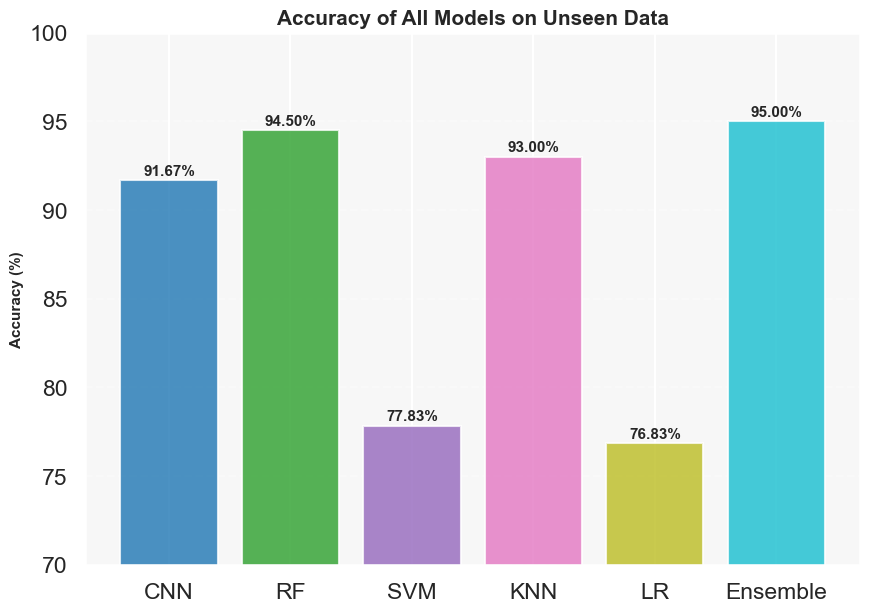

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")

plt.figure(figsize=(10,7))
colors = plt.get_cmap('tab10', 6)
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies22 = [cnn_acc22, rf_acc22, svm_acc22, knn_acc22, lr_acc22, acc_ensemble]

bars = plt.bar(models, accuracies22, color=[colors(i) for i in range(6)], alpha=0.8)
import numpy as np

plt.ylim(70, 100)
plt.ylabel("Accuracy (%)", fontsize=11, weight='bold')
plt.title("Accuracy of All Models on Unseen Data", fontsize=15, weight='bold')

for bar, acc in zip(bars, accuracies22):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.3, f"{acc:.2f}%", 
             ha='center', fontsize=11, weight='bold') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.subplots_adjust(top=0.88, bottom=0.12)

plt.show()




Ensemble Unseen Data  AUC Score: 0.9945777777777778


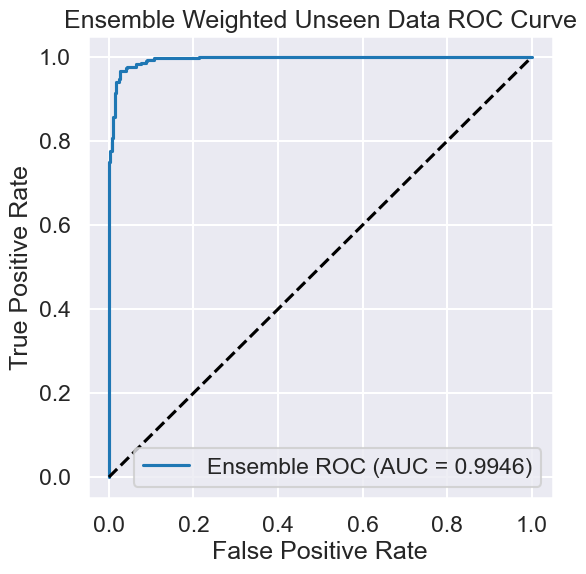

In [ ]:
ensemble_probs = weighted_sum32

fpr, tpr, thresholds = roc_curve(y, ensemble_probs)
roc_auc32 = auc(fpr, tpr)

print("\nEnsemble Unseen Data  AUC Score:", roc_auc32)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc32:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Unseen Data ROC Curve')
plt.legend(loc="lower right")
plt.show()


glcm_features below

CNN=0.948  RF=0.909  SVM=0.675  KNN=0.675  LR=0.614

Weights used for soft voting: [0.24807966 0.23783784 0.17667141 0.17667141 0.16073969]
Preds shape: (920, 5)
weighted_sum shape: (920,)

Weighted Soft Voting Ensemble Accuracy: 0.9565217391304348

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       417
           1       0.94      0.98      0.96       503

    accuracy                           0.96       920
   macro avg       0.96      0.95      0.96       920
weighted avg       0.96      0.96      0.96       920


Confusion Matrix:
 [[388  29]
 [ 11 492]]


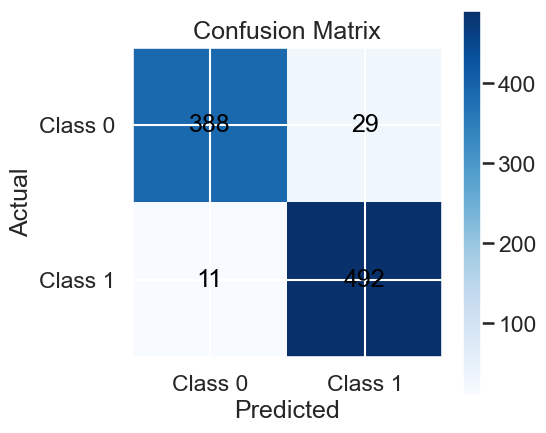

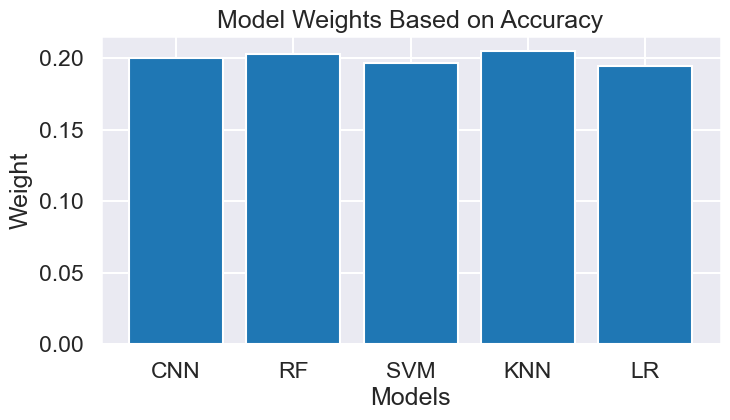


Ensemble Validation Data  AUC Score: 0.9923099293924701


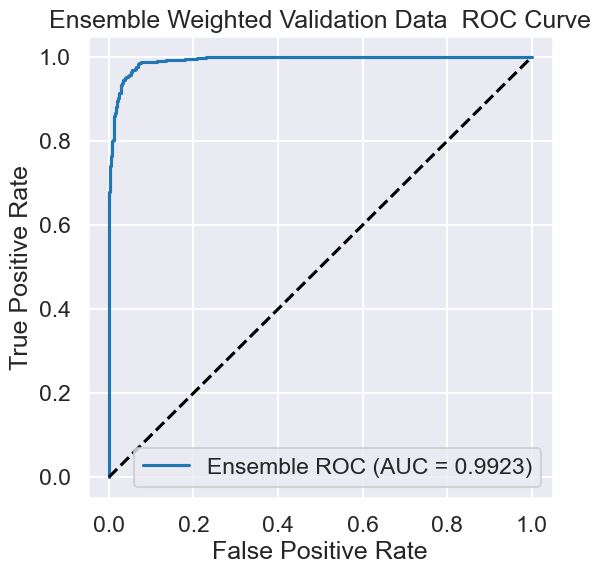

In [ ]:
print(f"CNN={cnn_acc:.3f}  RF={h41:.3f}  SVM={h42:.3f}  KNN={h43:.3f}  LR={h44:.3f}")
accuracies = np.array([cnn_acc,h41, h42, h43, h44], dtype=float)

if accuracies.sum() == 0:
    accuracies = np.ones_like(accuracies)

weights11 = accuracies / accuracies.sum()
print("\nWeights used for soft voting:", weights11)

preds = np.vstack([pp1, pp24, pp34, pp44, pp54]).T
print("Preds shape:", preds.shape)    

weighted_sum41 = np.dot(preds, weights11)
print("weighted_sum shape:", weighted_sum41.shape) 

Ensemble_prediction = (weighted_sum41 >= 0.5).astype(int)

ens_acc = accuracy_score(y_test, Ensemble_prediction)
print("\nWeighted Soft Voting Ensemble Accuracy:", ens_acc)

print("\nClassification Report:")
print(classification_report(y_test, Ensemble_prediction))

cm = confusion_matrix(y_test, Ensemble_prediction)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

labels = ["CNN","RF","SVM","KNN","LR"]

plt.figure(figsize=(8,4))
plt.bar(labels, weights1)
plt.title("Model Weights Based on Accuracy")
plt.ylabel("Weight")
plt.xlabel("Models")
plt.show()

ensemble_probs = weighted_sum41   

fpr, tpr, thresholds = roc_curve(y_test, ensemble_probs)
roc_auc41 = auc(fpr, tpr)

print("\nEnsemble Validation Data  AUC Score:", roc_auc41)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc41:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Validation Data  ROC Curve')
plt.legend(loc="lower right")
plt.show()


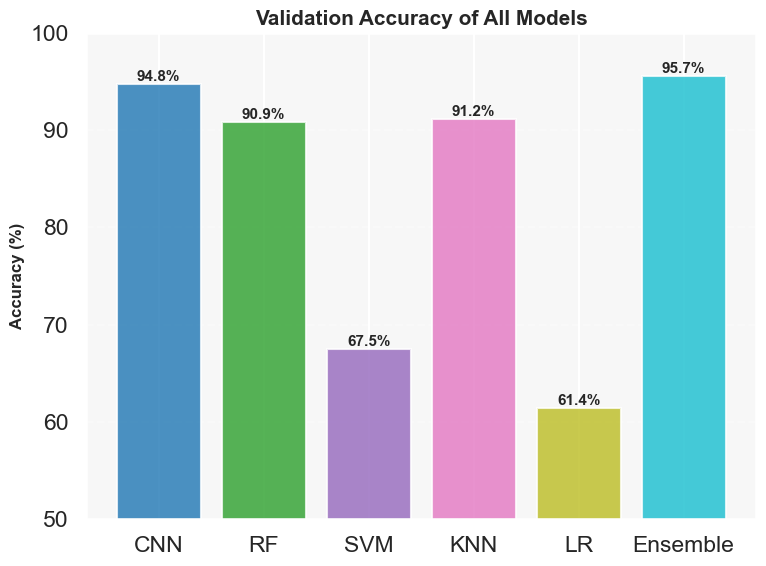

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")
plt.figure(figsize=(8,6))

colors = plt.get_cmap('tab10', 6)

cnn_acc1 = accuracy_score(y_test, (np.array(pred1))) * 100
rf_acc2  = accuracy_score(y_test, (np.array(pred24))) * 100
svm_acc3 = accuracy_score(y_test, (np.array(pred_wave_hog_svm ))) * 100
knn_acc4 = accuracy_score(y_test, (np.array(pred_wave_hog_knn ))) * 100
lr_acc5  = accuracy_score(y_test, (np.array(pred_wave_hog_lr ))) * 100
ens_acc11  = accuracy_score(y_test, (np.array(Ensemble_prediction))) * 100
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies1 = [cnn_acc1, rf_acc2, svm_acc3, knn_acc4, lr_acc5, ens_acc11]

plt.bar(models, accuracies1, color=[colors(i) for i in range(6)], alpha=0.8)
plt.ylim(50, 100)
plt.ylabel("Accuracy (%)", fontsize=12, weight='bold')
plt.title("Validation Accuracy of All Models", fontsize=15, weight='bold')

for i, v in enumerate(accuracies1):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=11, weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.tight_layout()
plt.show()


In [ ]:
unseen_feats   = extract_glcm_features(x_flat)
preds_rf   = rf4.predict_proba(unseen_feats)[:, 1]
preds_svm  = svm4.predict_proba(unseen_feats)[:, 1]
preds_knn  = knn4.predict_proba(unseen_feats)[:, 1]
preds_lr   = lr4.predict_proba(unseen_feats)[:, 1]
preds_cnn = cnn.predict(x_cnn).flatten()


p_cnn = (preds_cnn >= 0.5).astype(int)
p_rf  = (preds_rf  >= 0.5).astype(int)
p_svm = (preds_svm >= 0.5).astype(int)
p_knn = (preds_knn >= 0.5).astype(int)
p_lr  = (preds_lr  >= 0.5).astype(int)

cnn_acc22 = accuracy_score(y, p_cnn)
rf_acc22  = accuracy_score(y, p_rf)
svm_acc22 = accuracy_score(y, p_svm)
knn_acc22 = accuracy_score(y, p_knn)
lr_acc22  = accuracy_score(y, p_lr)

cnn_acc22= cnn_acc22*100
rf_acc22=rf_acc22*100
svm_acc22 = svm_acc22*100
knn_acc22 = knn_acc22*100
lr_acc22  = lr_acc22*100



preds_stack = np.vstack([preds_cnn, preds_rf, preds_svm, preds_knn, preds_lr]).T

weighted_sum42 = np.dot(preds_stack, weights11)
ensemble_pred = (weighted_sum42 >= 0.5).astype(int)

acc_ensemble = accuracy_score(y, ensemble_pred)
acc_ensemble=acc_ensemble*100

print("\n==============================")
print("ACCURACY SUMMARY of All Models")
print("==============================")

print(f"Total Images     : {len(y)}\n")
print(f"CNN Accuracy     : {cnn_acc22:.2f}%")
print(f"RF Accuracy      : {rf_acc22:.2f}%")
print(f"SVM Accuracy     : {svm_acc22:.2f}%")
print(f"KNN Accuracy     : {knn_acc22:.2f}%")
print(f"LR Accuracy      : {lr_acc22:.2f}%")

print("--------------------------------")
print(f"Ensemble Accuracy: {acc_ensemble:.2f}%")
print("--------------------------------")


print("\n==============================")
print("PER-IMAGE MODEL PREDICTIONS")
print("==============================\n")

for i, file in enumerate(filenames):

   ''' print(
        f"{file:25s} | "
        f"CNN={p_cnn[i]} ({preds_cnn[i]:.3f}) | "
        f"RF={p_rf[i]} ({preds_rf[i]:.3f}) | "
        f"SVM={p_svm[i]} ({preds_svm[i]:.3f}) | "
        f"KNN={p_knn[i]} ({preds_knn[i]:.3f}) | "
        f"LR={p_lr[i]} ({preds_lr[i]:.3f}) | "
        f"Ensemble  = {ensemble_pred[i]}" 
    )
'''
print("Classification Report - CNN:")
print(classification_report(y, p_cnn))
print("Classification Report - RF:")
print(classification_report(y, p_rf))
print("Classification Report - SVM:")
print(classification_report(y, p_svm))
print("Classification Report - KNN:")
print(classification_report(y, p_knn))
print("Classification Report - LR:")
print(classification_report(y, p_lr))
print("Classification Report - ENSEMBLE MODELS:")
print(classification_report(y, ensemble_pred))

19/19 [==============================] - 1s 52ms/step

ACCURACY SUMMARY of All Models
Total Images     : 600

CNN Accuracy     : 91.67%
RF Accuracy      : 88.67%
SVM Accuracy     : 69.00%
KNN Accuracy     : 88.33%
LR Accuracy      : 56.33%
--------------------------------
Ensemble Accuracy: 95.50%
--------------------------------

PER-IMAGE MODEL PREDICTIONS

Classification Report - CNN:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       300
           1       0.94      0.89      0.91       300

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600

Classification Report - RF:
              precision    recall  f1-score   support

           0       0.84      0.96      0.89       300
           1       0.96      0.81      0.88       300

    accuracy                           0.89       600
   macro avg       0.90      0.89   

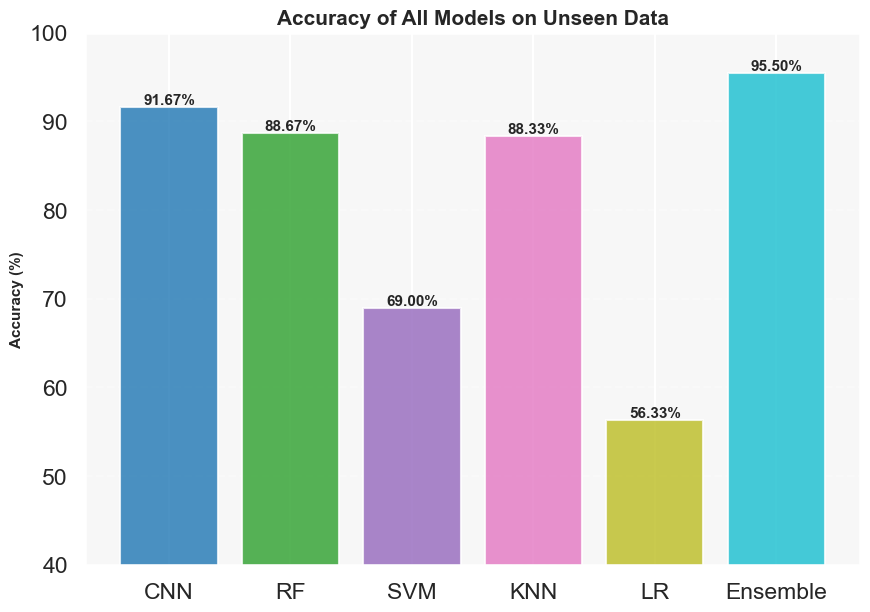

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")

plt.figure(figsize=(10,7))
colors = plt.get_cmap('tab10', 6)
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies22 = [cnn_acc22, rf_acc22, svm_acc22, knn_acc22, lr_acc22, acc_ensemble]

bars = plt.bar(models, accuracies22, color=[colors(i) for i in range(6)], alpha=0.8)
import numpy as np

plt.ylim(40, 100)
plt.ylabel("Accuracy (%)", fontsize=11, weight='bold')
plt.title("Accuracy of All Models on Unseen Data", fontsize=15, weight='bold')

for bar, acc in zip(bars, accuracies22):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.3, f"{acc:.2f}%", 
             ha='center', fontsize=11, weight='bold') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.subplots_adjust(top=0.88, bottom=0.12)

plt.show()




Ensemble Unseen Data  AUC Score: 0.9923444444444445


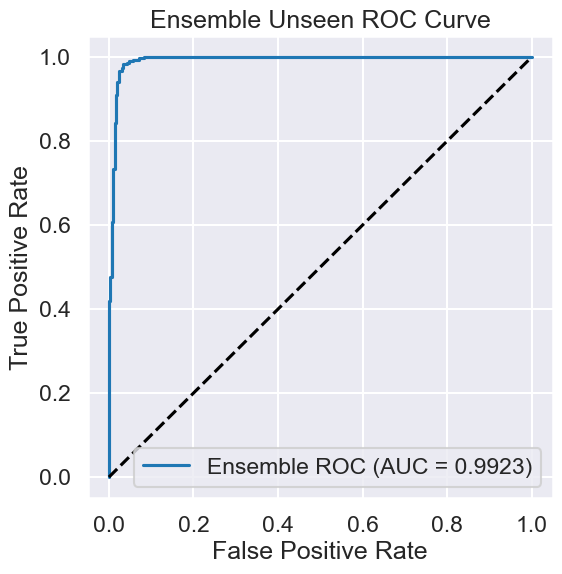

In [ ]:
ensemble_probs = weighted_sum42

fpr, tpr, thresholds = roc_curve(y, ensemble_probs)
roc_auc42 = auc(fpr, tpr)

print("\nEnsemble Unseen Data  AUC Score:", roc_auc42)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc42:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Unseen ROC Curve')
plt.legend(loc="lower right")
plt.show()


lbp_features

CNN=0.948  RF=0.663  SVM=0.547  KNN=0.650  LR=0.453

Weights used for soft voting: [0.29066667 0.20333333 0.16766667 0.19933333 0.139     ]
Preds shape: (920, 5)
weighted_sum shape: (920,)

Weighted Soft Voting Ensemble Accuracy: 0.8695652173913043

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       417
           1       0.86      0.91      0.88       503

    accuracy                           0.87       920
   macro avg       0.87      0.87      0.87       920
weighted avg       0.87      0.87      0.87       920


Confusion Matrix:
 [[343  74]
 [ 46 457]]


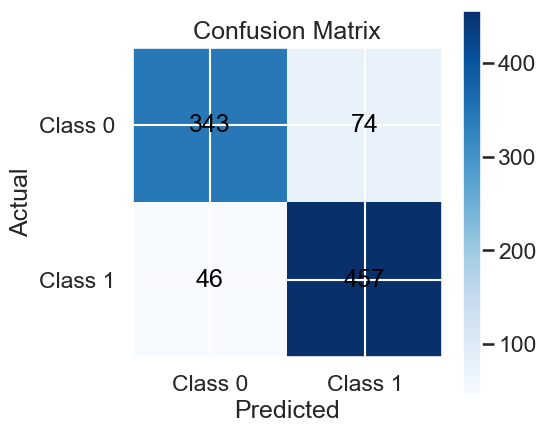

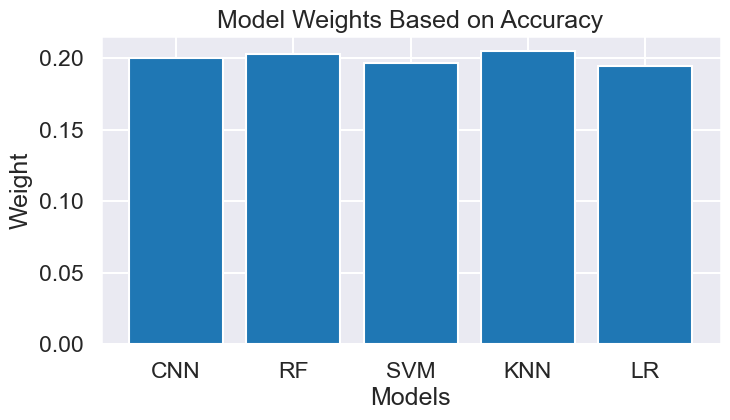


Ensemble Validation Data  AUC Score: 0.9424937187426997


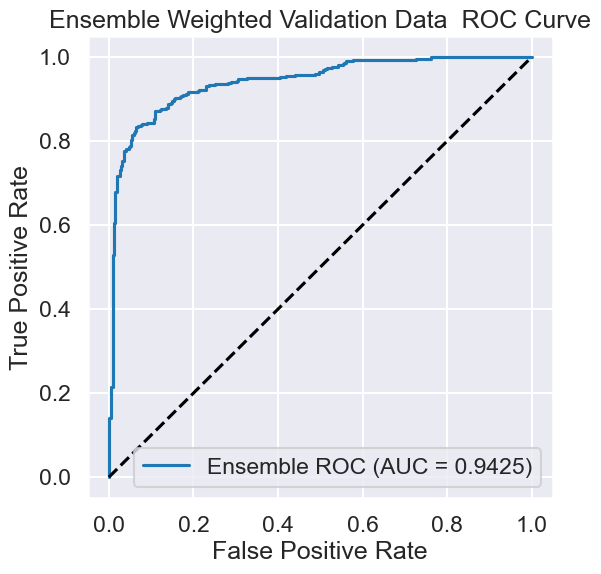

In [ ]:
print(f"CNN={cnn_acc:.3f}  RF={h51:.3f}  SVM={h52:.3f}  KNN={h53:.3f}  LR={h54:.3f}")

accuracies = np.array([cnn_acc,h51, h52, h53, h54], dtype=float)

if accuracies.sum() == 0:
    accuracies = np.ones_like(accuracies)

weights11 = accuracies / accuracies.sum()
print("\nWeights used for soft voting:", weights11)

preds = np.vstack([pp1, pp25, pp35, pp45, pp55]).T
print("Preds shape:", preds.shape)      

weighted_sum51 = np.dot(preds, weights1)
print("weighted_sum shape:", weighted_sum51.shape)   

Ensemble_prediction = (weighted_sum51 >= 0.5).astype(int)

ens_acc = accuracy_score(y_test, Ensemble_prediction)
print("\nWeighted Soft Voting Ensemble Accuracy:", ens_acc)

print("\nClassification Report:")
print(classification_report(y_test, Ensemble_prediction))

cm = confusion_matrix(y_test, Ensemble_prediction)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


labels = ["CNN","RF","SVM","KNN","LR"]

plt.figure(figsize=(8,4))
plt.bar(labels, weights1)
plt.title("Model Weights Based on Accuracy")
plt.ylabel("Weight")
plt.xlabel("Models")
plt.show()

ensemble_probs = weighted_sum51   

fpr, tpr, thresholds = roc_curve(y_test, ensemble_probs)
roc_auc51 = auc(fpr, tpr)

print("\nEnsemble Validation Data  AUC Score:", roc_auc51)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc51:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Validation Data  ROC Curve')
plt.legend(loc="lower right")
plt.show()


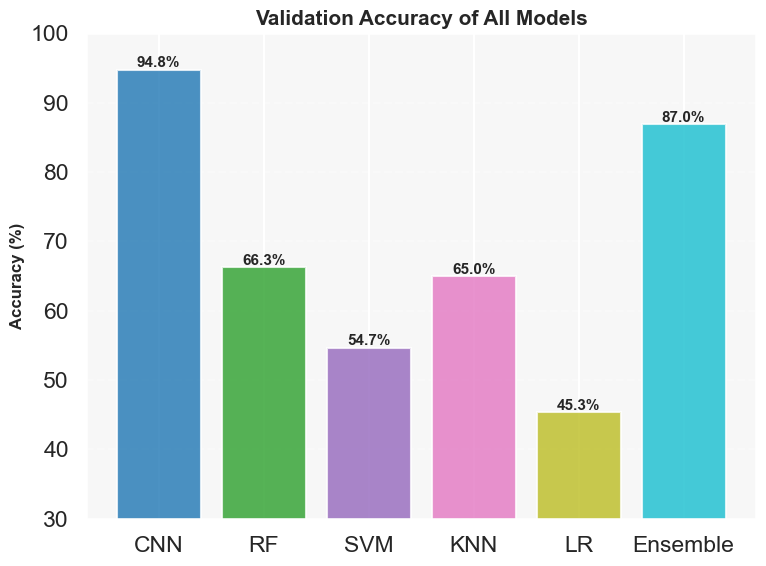

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")
plt.figure(figsize=(8,6))

colors = plt.get_cmap('tab10', 6)

cnn_acc1 = accuracy_score(y_test, (np.array(pred1))) * 100
rf_acc2  = accuracy_score(y_test, (np.array(pred25))) * 100
svm_acc3 = accuracy_score(y_test, (np.array(pred_lbp_svm ))) * 100
knn_acc4 = accuracy_score(y_test, (np.array(pred_lbp_knn ))) * 100
lr_acc5  = accuracy_score(y_test, (np.array(pred_lbp_lr ))) * 100
ens_acc11  = accuracy_score(y_test, (np.array(Ensemble_prediction))) * 100
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies1 = [cnn_acc1, rf_acc2, svm_acc3, knn_acc4, lr_acc5, ens_acc11]

plt.bar(models, accuracies1, color=[colors(i) for i in range(6)], alpha=0.8)
plt.ylim(30, 100)
plt.ylabel("Accuracy (%)", fontsize=12, weight='bold')
plt.title("Validation Accuracy of All Models", fontsize=15, weight='bold')

for i, v in enumerate(accuracies1):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=11, weight='bold')

# Style
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.tight_layout()
plt.show()


In [ ]:
unseen_feats   = extract_lbp_features(x_flat)
preds_rf   = rf5.predict_proba(unseen_feats)[:, 1]
preds_svm  = svm5.predict_proba(unseen_feats)[:, 1]
preds_knn  = knn5.predict_proba(unseen_feats)[:, 1]
preds_lr   = lr5.predict_proba(unseen_feats)[:, 1]
preds_cnn = cnn.predict(x_cnn).flatten()


p_cnn = (preds_cnn >= 0.5).astype(int)
p_rf  = (preds_rf  >= 0.5).astype(int)
p_svm = (preds_svm >= 0.5).astype(int)
p_knn = (preds_knn >= 0.5).astype(int)
p_lr  = (preds_lr  >= 0.5).astype(int)

cnn_acc22 = accuracy_score(y, p_cnn)
rf_acc22  = accuracy_score(y, p_rf)
svm_acc22 = accuracy_score(y, p_svm)
knn_acc22 = accuracy_score(y, p_knn)
lr_acc22  = accuracy_score(y, p_lr)

cnn_acc22= cnn_acc22*100
rf_acc22=rf_acc22*100
svm_acc22 = svm_acc22*100
knn_acc22 = knn_acc22*100
lr_acc22  = lr_acc22*100



preds_stack = np.vstack([preds_cnn, preds_rf, preds_svm, preds_knn, preds_lr]).T

weighted_sum52 = np.dot(preds_stack, weights11)
ensemble_pred = (weighted_sum52 >= 0.5).astype(int)

acc_ensemble = accuracy_score(y, ensemble_pred)
acc_ensemble=acc_ensemble*100

print("\n==============================")
print("ACCURACY SUMMARY of All Models")
print("==============================")

print(f"Total Images     : {len(y)}\n")
print(f"CNN Accuracy     : {cnn_acc22:.2f}%")
print(f"RF Accuracy      : {rf_acc22:.2f}%")
print(f"SVM Accuracy     : {svm_acc22:.2f}%")
print(f"KNN Accuracy     : {knn_acc22:.2f}%")
print(f"LR Accuracy      : {lr_acc22:.2f}%")

print("--------------------------------")
print(f"Ensemble Accuracy: {acc_ensemble:.2f}%")
print("--------------------------------")


print("\n==============================")
print("PER-IMAGE MODEL PREDICTIONS")
print("==============================\n")

for i, file in enumerate(filenames):

   ''' print(
        f"{file:25s} | "
        f"CNN={p_cnn[i]} ({preds_cnn[i]:.3f}) | "
        f"RF={p_rf[i]} ({preds_rf[i]:.3f}) | "
        f"SVM={p_svm[i]} ({preds_svm[i]:.3f}) | "
        f"KNN={p_knn[i]} ({preds_knn[i]:.3f}) | "
        f"LR={p_lr[i]} ({preds_lr[i]:.3f}) | "
        f"Ensemble  = {ensemble_pred[i]}" 
    )
'''
print("Classification Report - CNN:")
print(classification_report(y, p_cnn))
print("Classification Report - RF:")
print(classification_report(y, p_rf))
print("Classification Report - SVM:")
print(classification_report(y, p_svm))
print("Classification Report - KNN:")
print(classification_report(y, p_knn))
print("Classification Report - LR:")
print(classification_report(y, p_lr))
print("Classification Report - ENSEMBLE MODELS:")
print(classification_report(y, ensemble_pred))

19/19 [==============================] - 1s 61ms/step

ACCURACY SUMMARY of All Models
Total Images     : 600

CNN Accuracy     : 91.67%
RF Accuracy      : 67.50%
SVM Accuracy     : 50.00%
KNN Accuracy     : 67.33%
LR Accuracy      : 50.00%
--------------------------------
Ensemble Accuracy: 92.00%
--------------------------------

PER-IMAGE MODEL PREDICTIONS

Classification Report - CNN:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       300
           1       0.94      0.89      0.91       300

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600

Classification Report - RF:
              precision    recall  f1-score   support

           0       0.93      0.38      0.54       300
           1       0.61      0.97      0.75       300

    accuracy                           0.68       600
   macro avg       0.77      0.68   

c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\shaha\anaconda3\envs\researchwork\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c

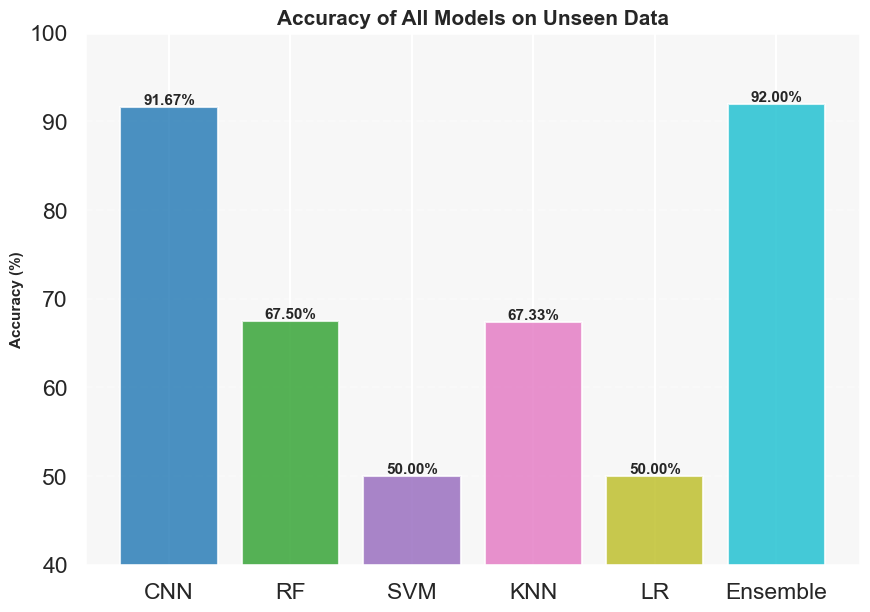

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")


plt.figure(figsize=(10,7))
colors = plt.get_cmap('tab10', 6)
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies22 = [cnn_acc22, rf_acc22, svm_acc22, knn_acc22, lr_acc22, acc_ensemble]

bars = plt.bar(models, accuracies22, color=[colors(i) for i in range(6)], alpha=0.8)
import numpy as np

plt.ylim(40, 100)
plt.ylabel("Accuracy (%)", fontsize=11, weight='bold')
plt.title("Accuracy of All Models on Unseen Data", fontsize=15, weight='bold')

for bar, acc in zip(bars, accuracies22):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.3, f"{acc:.2f}%", 
             ha='center', fontsize=11, weight='bold') 


plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.subplots_adjust(top=0.88, bottom=0.12)

plt.show()




Ensemble Unseen AUC Score: 0.9783777777777778


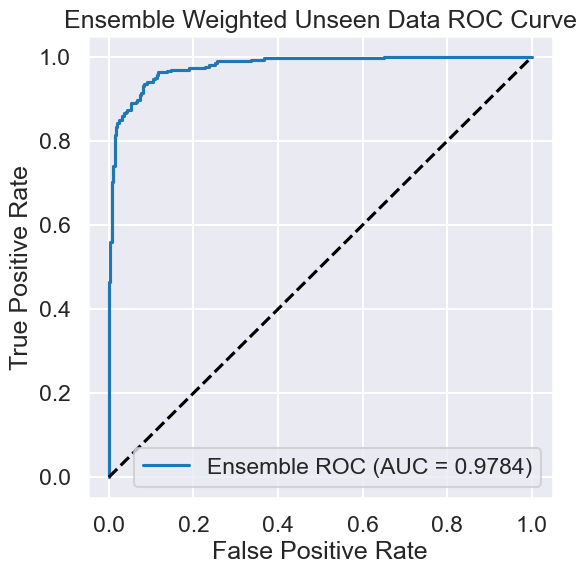

In [ ]:
ensemble_probs = weighted_sum52

fpr, tpr, thresholds = roc_curve(y, ensemble_probs)
roc_auc52 = auc(fpr, tpr)

print("\nEnsemble Unseen AUC Score:", roc_auc52)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc52:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Unseen Data ROC Curve')
plt.legend(loc="lower right")
plt.show()


wavelet_cnn_features below

CNN=0.948  RF=0.949  SVM=0.886  KNN=0.972  LR=0.876

Weights used for soft voting: [0.20469484 0.20492958 0.19131455 0.20985915 0.18920188]
Preds shape: (920, 5)
weighted_sum shape: (920,)

Weighted Soft Voting Ensemble Accuracy: 0.975

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       417
           1       0.97      0.98      0.98       503

    accuracy                           0.97       920
   macro avg       0.98      0.97      0.97       920
weighted avg       0.98      0.97      0.97       920


Confusion Matrix:
 [[404  13]
 [ 10 493]]


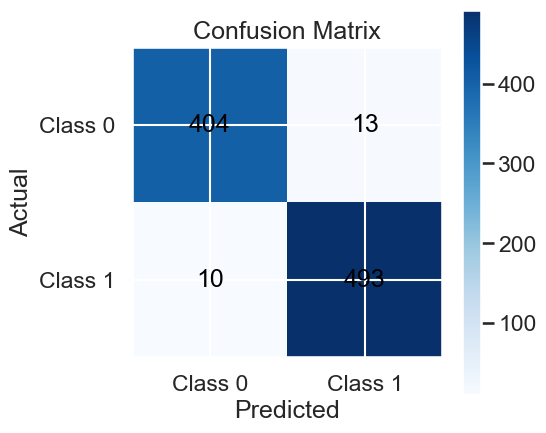

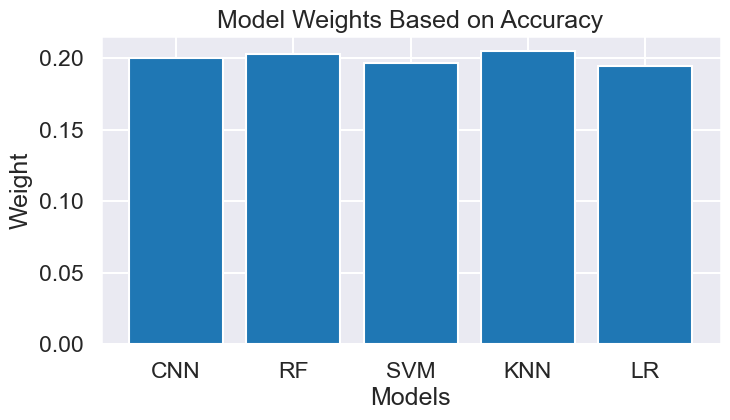


Ensemble Validation Data  AUC Score: 0.9961954889368823


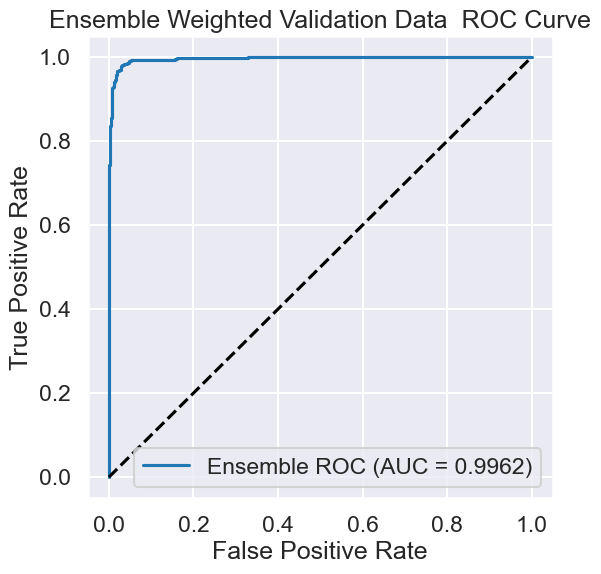

In [ ]:
print(f"CNN={cnn_acc:.3f}  RF={h61:.3f}  SVM={h62:.3f}  KNN={h63:.3f}  LR={h64:.3f}")
accuracies = np.array([cnn_acc,h61, h62, h63, h64], dtype=float)

if accuracies.sum() == 0:
    accuracies = np.ones_like(accuracies)

weights11 = accuracies / accuracies.sum()
print("\nWeights used for soft voting:", weights11)

preds = np.vstack([pp1, pp26, pp36, pp46, pp56]).T
print("Preds shape:", preds.shape)     

weighted_sum61 = np.dot(preds, weights11)
print("weighted_sum shape:", weighted_sum61.shape)  

Ensemble_prediction = (weighted_sum61 >= 0.5).astype(int)

ens_acc = accuracy_score(y_test, Ensemble_prediction)
print("\nWeighted Soft Voting Ensemble Accuracy:", ens_acc)

print("\nClassification Report:")
print(classification_report(y_test, Ensemble_prediction))

cm = confusion_matrix(y_test, Ensemble_prediction)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ---------------------------
# 7) WEIGHT VISUALIZATION
# ---------------------------
labels = ["CNN","RF","SVM","KNN","LR"]

plt.figure(figsize=(8,4))
plt.bar(labels, weights1)
plt.title("Model Weights Based on Accuracy")
plt.ylabel("Weight")
plt.xlabel("Models")
plt.show()


ensemble_probs = weighted_sum61 

fpr, tpr, thresholds = roc_curve(y_test, ensemble_probs)
roc_auc61= auc(fpr, tpr)

print("\nEnsemble Validation Data  AUC Score:", roc_auc61)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc61:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Validation Data  ROC Curve')
plt.legend(loc="lower right")
plt.show()


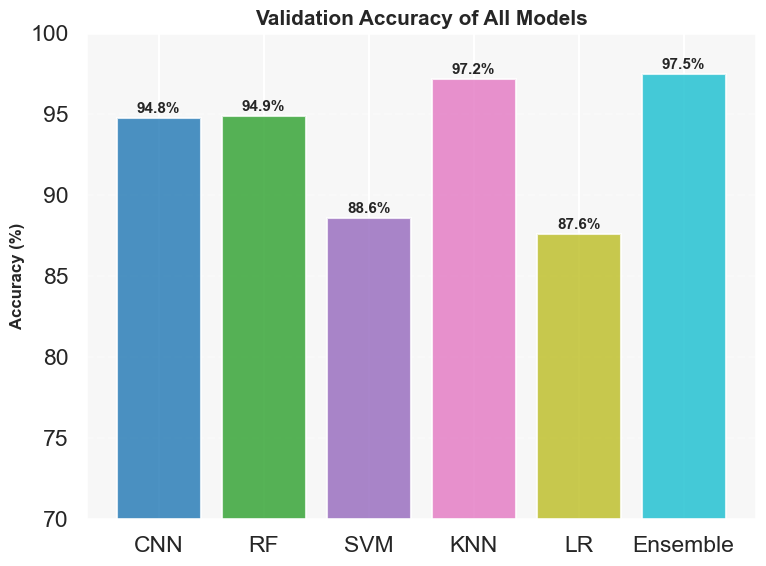

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")
plt.figure(figsize=(8,6))

colors = plt.get_cmap('tab10', 6)

cnn_acc1 = accuracy_score(y_test, (np.array(pred1))) * 100
rf_acc2  = accuracy_score(y_test, (np.array(pred29))) * 100
svm_acc3 = accuracy_score(y_test, (np.array(pred_wave_cnn_svm ))) * 100
knn_acc4 = accuracy_score(y_test, (np.array(pred_wave_cnn_knn ))) * 100
lr_acc5  = accuracy_score(y_test, (np.array(pred_wave_cnn_lr ))) * 100
ens_acc11  = accuracy_score(y_test, (np.array(Ensemble_prediction))) * 100
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies1 = [cnn_acc1, rf_acc2, svm_acc3, knn_acc4, lr_acc5, ens_acc11]


plt.bar(models, accuracies1, color=[colors(i) for i in range(6)], alpha=0.8)
plt.ylim(70, 100)
plt.ylabel("Accuracy (%)", fontsize=12, weight='bold')
plt.title("Validation Accuracy of All Models", fontsize=15, weight='bold')

for i, v in enumerate(accuracies1):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=11, weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.tight_layout()
plt.show()


In [ ]:
unseen_feats   = extract_wavelet_cnn_features(x_flat,cnn_model_path)
preds_rf   = rf6.predict_proba(unseen_feats)[:, 1]
preds_svm  = svm6.predict_proba(unseen_feats)[:, 1]
preds_knn  = knn6.predict_proba(unseen_feats)[:, 1]
preds_lr   = lr6.predict_proba(unseen_feats)[:, 1]
preds_cnn = cnn.predict(x_cnn).flatten()


p_cnn = (preds_cnn >= 0.5).astype(int)
p_rf  = (preds_rf  >= 0.5).astype(int)
p_svm = (preds_svm >= 0.5).astype(int)
p_knn = (preds_knn >= 0.5).astype(int)
p_lr  = (preds_lr  >= 0.5).astype(int)

cnn_acc22 = accuracy_score(y, p_cnn)
rf_acc22  = accuracy_score(y, p_rf)
svm_acc22 = accuracy_score(y, p_svm)
knn_acc22 = accuracy_score(y, p_knn)
lr_acc22  = accuracy_score(y, p_lr)

cnn_acc22= cnn_acc22*100
rf_acc22=rf_acc22*100
svm_acc22 = svm_acc22*100
knn_acc22 = knn_acc22*100
lr_acc22  = lr_acc22*100



preds_stack = np.vstack([preds_cnn, preds_rf, preds_svm, preds_knn, preds_lr]).T

weighted_sum62 = np.dot(preds_stack, weights11)
ensemble_pred = (weighted_sum62 >= 0.5).astype(int)

acc_ensemble = accuracy_score(y, ensemble_pred)
acc_ensemble=acc_ensemble*100

print("\n==============================")
print("ACCURACY SUMMARY of All Models")
print("==============================")

print(f"Total Images     : {len(y)}\n")
print(f"CNN Accuracy     : {cnn_acc22:.2f}%")
print(f"RF Accuracy      : {rf_acc22:.2f}%")
print(f"SVM Accuracy     : {svm_acc22:.2f}%")
print(f"KNN Accuracy     : {knn_acc22:.2f}%")
print(f"LR Accuracy      : {lr_acc22:.2f}%")

print("--------------------------------")
print(f"Ensemble Accuracy: {acc_ensemble:.2f}%")
print("--------------------------------")


print("\n==============================")
print("PER-IMAGE MODEL PREDICTIONS")
print("==============================\n")

for i, file in enumerate(filenames):

   ''' print(
        f"{file:25s} | "
        f"CNN={p_cnn[i]} ({preds_cnn[i]:.3f}) | "
        f"RF={p_rf[i]} ({preds_rf[i]:.3f}) | "
        f"SVM={p_svm[i]} ({preds_svm[i]:.3f}) | "
        f"KNN={p_knn[i]} ({preds_knn[i]:.3f}) | "
        f"LR={p_lr[i]} ({preds_lr[i]:.3f}) | "
        f"Ensemble  = {ensemble_pred[i]}" 
    )
'''
print("Classification Report - CNN:")
print(classification_report(y, p_cnn))
print("Classification Report - RF:")
print(classification_report(y, p_rf))
print("Classification Report - SVM:")
print(classification_report(y, p_svm))
print("Classification Report - KNN:")
print(classification_report(y, p_knn))
print("Classification Report - LR:")
print(classification_report(y, p_lr))
print("Classification Report - ENSEMBLE MODELS:")
print(classification_report(y, ensemble_pred))

19/19 [==============================] - 1s 50ms/step

ACCURACY SUMMARY of All Models
Total Images     : 600

CNN Accuracy     : 91.67%
RF Accuracy      : 93.00%
SVM Accuracy     : 77.83%
KNN Accuracy     : 93.00%
LR Accuracy      : 76.50%
--------------------------------
Ensemble Accuracy: 95.17%
--------------------------------

PER-IMAGE MODEL PREDICTIONS

Classification Report - CNN:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       300
           1       0.94      0.89      0.91       300

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600

Classification Report - RF:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       300
           1       0.97      0.88      0.93       300

    accuracy                           0.93       600
   macro avg       0.93      0.93   

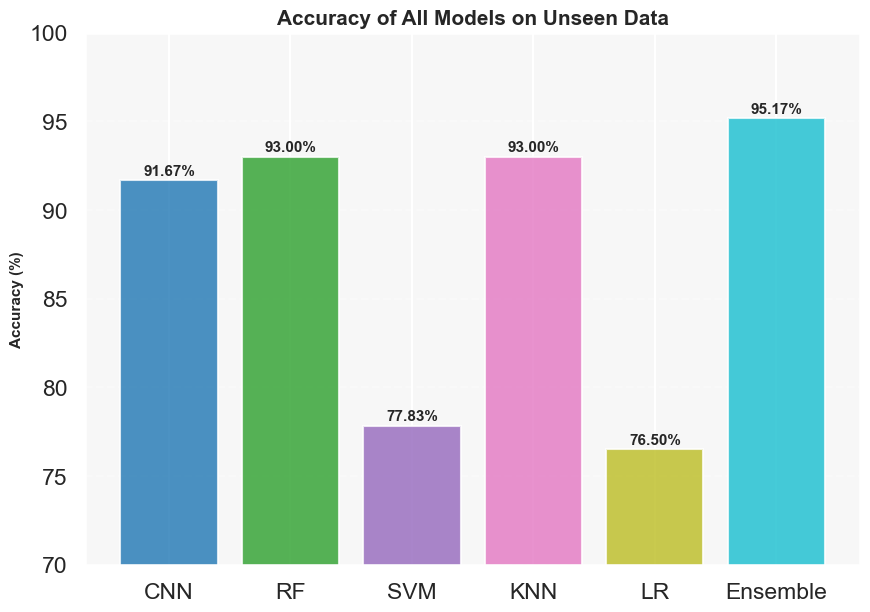

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")


plt.figure(figsize=(10,7))
colors = plt.get_cmap('tab10', 6)
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies22 = [cnn_acc22, rf_acc22, svm_acc22, knn_acc22, lr_acc22, acc_ensemble]

bars = plt.bar(models, accuracies22, color=[colors(i) for i in range(6)], alpha=0.8)
import numpy as np

plt.ylim(70, 100)
plt.ylabel("Accuracy (%)", fontsize=11, weight='bold')
plt.title("Accuracy of All Models on Unseen Data", fontsize=15, weight='bold')

for bar, acc in zip(bars, accuracies22):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.3, f"{acc:.2f}%", 
             ha='center', fontsize=11, weight='bold') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.subplots_adjust(top=0.88, bottom=0.12)

plt.show()




Ensemble Unseen Data AUC Score: 0.9923444444444445


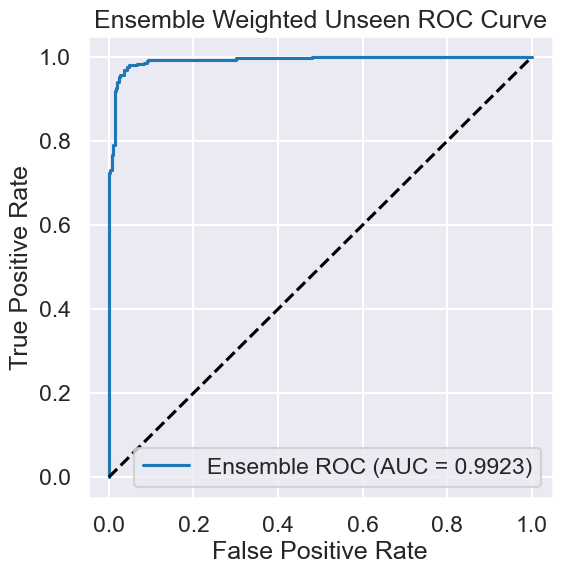

In [ ]:
ensemble_probs = weighted_sum62
fpr, tpr, thresholds = roc_curve(y, ensemble_probs)
roc_auc62 = auc(fpr, tpr)

print("\nEnsemble Unseen Data AUC Score:", roc_auc62)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc62:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Unseen ROC Curve')
plt.legend(loc="lower right")
plt.show()


extract_hog_cnn_features below

CNN=0.948  RF=0.928  SVM=0.688  KNN=0.971  LR=0.740

Weights used for soft voting: [0.2217137  0.21713705 0.16094584 0.22705314 0.17315027]
Preds shape: (920, 5)
weighted_sum shape: (920,)

Weighted Soft Voting Ensemble Accuracy: 0.9684782608695652

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       417
           1       0.96      0.99      0.97       503

    accuracy                           0.97       920
   macro avg       0.97      0.97      0.97       920
weighted avg       0.97      0.97      0.97       920


Confusion Matrix:
 [[395  22]
 [  7 496]]


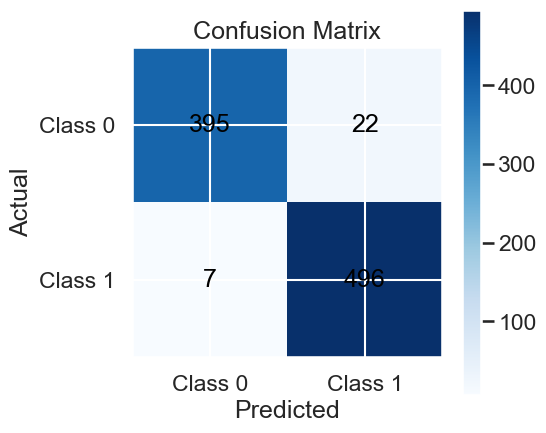

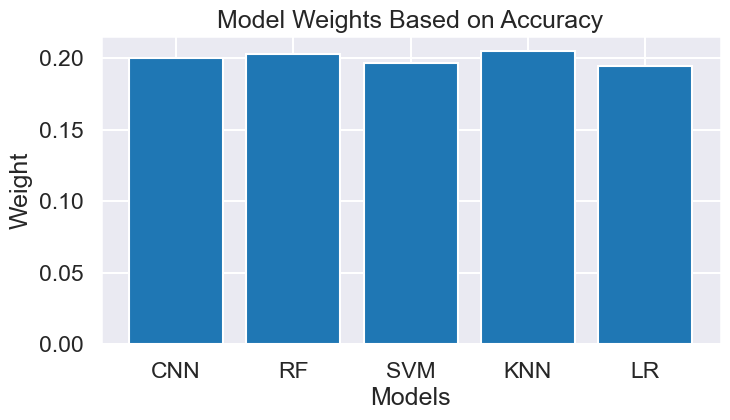


Ensemble Validation Data  AUC Score: 0.9967056176132653


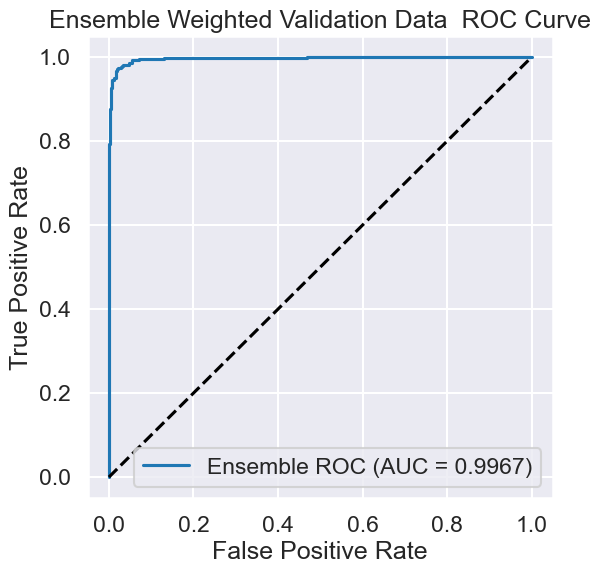

In [ ]:
print(f"CNN={cnn_acc:.3f}  RF={h71:.3f}  SVM={h72:.3f}  KNN={h73:.3f}  LR={h74:.3f}")
accuracies = np.array([cnn_acc,h71, h72, h73, h74], dtype=float)

if accuracies.sum() == 0:
    accuracies = np.ones_like(accuracies)

weights11 = accuracies / accuracies.sum()
print("\nWeights used for soft voting:", weights11)

preds = np.vstack([pp1, pp27, pp37, pp47, pp57]).T
print("Preds shape:", preds.shape)     

weighted_sum71 = np.dot(preds, weights11)
print("weighted_sum shape:", weighted_sum71.shape)  

Ensemble_prediction = (weighted_sum71 >= 0.5).astype(int)

ens_acc = accuracy_score(y_test, Ensemble_prediction)
print("\nWeighted Soft Voting Ensemble Accuracy:", ens_acc)

print("\nClassification Report:")
print(classification_report(y_test, Ensemble_prediction))

cm = confusion_matrix(y_test, Ensemble_prediction)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

labels = ["CNN","RF","SVM","KNN","LR"]

plt.figure(figsize=(8,4))
plt.bar(labels, weights1)
plt.title("Model Weights Based on Accuracy")
plt.ylabel("Weight")
plt.xlabel("Models")
plt.show()

ensemble_probs = weighted_sum71  
fpr, tpr, thresholds = roc_curve(y_test, ensemble_probs)
roc_auc71 = auc(fpr, tpr)

print("\nEnsemble Validation Data  AUC Score:", roc_auc71)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc71:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Validation Data  ROC Curve')
plt.legend(loc="lower right")
plt.show()


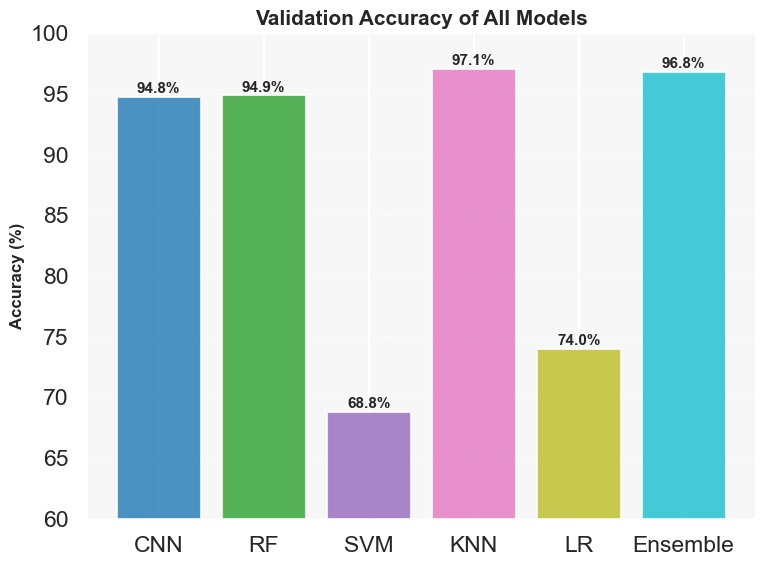

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")
plt.figure(figsize=(8,6))

colors = plt.get_cmap('tab10', 6)

cnn_acc1 = accuracy_score(y_test, (np.array(pred1))) * 100
rf_acc2  = accuracy_score(y_test, (np.array(pred29))) * 100
svm_acc3 = accuracy_score(y_test, (np.array(pred_hog_cnn_svm ))) * 100
knn_acc4 = accuracy_score(y_test, (np.array(pred_hog_cnn_knn ))) * 100
lr_acc5  = accuracy_score(y_test, (np.array(pred_hog_cnn_lr ))) * 100
ens_acc11  = accuracy_score(y_test, (np.array(Ensemble_prediction))) * 100
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies1 = [cnn_acc1, rf_acc2, svm_acc3, knn_acc4, lr_acc5, ens_acc11]


plt.bar(models, accuracies1, color=[colors(i) for i in range(6)], alpha=0.8)
plt.ylim(60, 100)
plt.ylabel("Accuracy (%)", fontsize=12, weight='bold')
plt.title("Validation Accuracy of All Models", fontsize=15, weight='bold')


for i, v in enumerate(accuracies1):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=11, weight='bold')


plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')

plt.tight_layout()
plt.show()


In [ ]:
unseen_feats   = extract_hog_cnn_features(x_flat,cnn_model_path)
preds_rf   = rf7.predict_proba(unseen_feats)[:, 1]
preds_svm  = svm7.predict_proba(unseen_feats)[:, 1]
preds_knn  = knn7.predict_proba(unseen_feats)[:, 1]
preds_lr   = lr7.predict_proba(unseen_feats)[:, 1]
preds_cnn = cnn.predict(x_cnn).flatten()


p_cnn = (preds_cnn >= 0.5).astype(int)
p_rf  = (preds_rf  >= 0.5).astype(int)
p_svm = (preds_svm >= 0.5).astype(int)
p_knn = (preds_knn >= 0.5).astype(int)
p_lr  = (preds_lr  >= 0.5).astype(int)

cnn_acc22 = accuracy_score(y, p_cnn)
rf_acc22  = accuracy_score(y, p_rf)
svm_acc22 = accuracy_score(y, p_svm)
knn_acc22 = accuracy_score(y, p_knn)
lr_acc22  = accuracy_score(y, p_lr)

cnn_acc22= cnn_acc22*100
rf_acc22=rf_acc22*100
svm_acc22 = svm_acc22*100
knn_acc22 = knn_acc22*100
lr_acc22  = lr_acc22*100



preds_stack = np.vstack([preds_cnn, preds_rf, preds_svm, preds_knn, preds_lr]).T

weighted_sum72 = np.dot(preds_stack, weights11)
ensemble_pred = (weighted_sum72 >= 0.5).astype(int)

acc_ensemble = accuracy_score(y, ensemble_pred)
acc_ensemble=acc_ensemble*100

print("\n==============================")
print("ACCURACY SUMMARY of All Models")
print("==============================")

print(f"Total Images     : {len(y)}\n")
print(f"CNN Accuracy     : {cnn_acc22:.2f}%")
print(f"RF Accuracy      : {rf_acc22:.2f}%")
print(f"SVM Accuracy     : {svm_acc22:.2f}%")
print(f"KNN Accuracy     : {knn_acc22:.2f}%")
print(f"LR Accuracy      : {lr_acc22:.2f}%")

print("--------------------------------")
print(f"Ensemble Accuracy: {acc_ensemble:.2f}%")
print("--------------------------------")


print("\n==============================")
print("PER-IMAGE MODEL PREDICTIONS")
print("==============================\n")

for i, file in enumerate(filenames):

   ''' print(
        f"{file:25s} | "
        f"CNN={p_cnn[i]} ({preds_cnn[i]:.3f}) | "
        f"RF={p_rf[i]} ({preds_rf[i]:.3f}) | "
        f"SVM={p_svm[i]} ({preds_svm[i]:.3f}) | "
        f"KNN={p_knn[i]} ({preds_knn[i]:.3f}) | "
        f"LR={p_lr[i]} ({preds_lr[i]:.3f}) | "
        f"Ensemble  = {ensemble_pred[i]}" 
    )
'''
print("Classification Report - CNN:")
print(classification_report(y, p_cnn))
print("Classification Report - RF:")
print(classification_report(y, p_rf))
print("Classification Report - SVM:")
print(classification_report(y, p_svm))
print("Classification Report - KNN:")
print(classification_report(y, p_knn))
print("Classification Report - LR:")
print(classification_report(y, p_lr))
print("Classification Report - ENSEMBLE MODELS:")
print(classification_report(y, ensemble_pred))

19/19 [==============================] - 1s 51ms/step

ACCURACY SUMMARY of All Models
Total Images     : 600

CNN Accuracy     : 91.67%
RF Accuracy      : 91.83%
SVM Accuracy     : 66.00%
KNN Accuracy     : 85.50%
LR Accuracy      : 67.17%
--------------------------------
Ensemble Accuracy: 94.83%
--------------------------------

PER-IMAGE MODEL PREDICTIONS

Classification Report - CNN:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       300
           1       0.94      0.89      0.91       300

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600

Classification Report - RF:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       300
           1       0.95      0.88      0.92       300

    accuracy                           0.92       600
   macro avg       0.92      0.92   

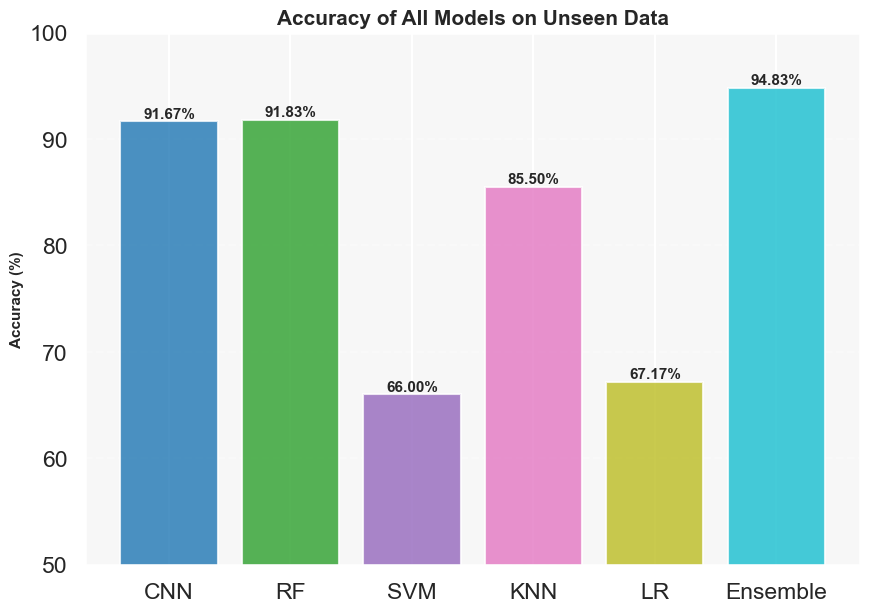

In [ ]:
sn.set_style("darkgrid")
sn.set_context("talk")


plt.figure(figsize=(10,7))
colors = plt.get_cmap('tab10', 6)
models = ['CNN', 'RF', 'SVM', 'KNN', 'LR', 'Ensemble']
accuracies22 = [cnn_acc22, rf_acc22, svm_acc22, knn_acc22, lr_acc22, acc_ensemble]

bars = plt.bar(models, accuracies22, color=[colors(i) for i in range(6)], alpha=0.8)

plt.ylim(50, 100)
plt.ylabel("Accuracy (%)", fontsize=11, weight='bold')
plt.title("Accuracy of All Models on Unseen Data", fontsize=15, weight='bold')

for bar, acc in zip(bars, accuracies22):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.3, f"{acc:.2f}%", 
             ha='center', fontsize=11, weight='bold') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_facecolor('#f7f7f7')


plt.subplots_adjust(top=0.88, bottom=0.12)

plt.show()




Ensemble Unseen Data AUC Score: 0.9926333333333334


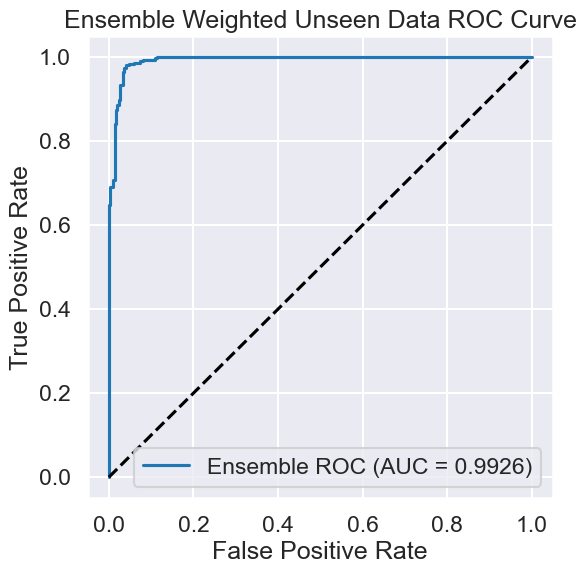

In [ ]:
ensemble_probs = weighted_sum72

fpr, tpr, thresholds = roc_curve(y, ensemble_probs)
roc_auc72 = auc(fpr, tpr)

print("\nEnsemble Unseen Data AUC Score:", roc_auc72)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Ensemble ROC (AUC = {roc_auc72:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Weighted Unseen Data ROC Curve')
plt.legend(loc="lower right")
plt.show()


BAR CHART OF ALL FEATURE EXTRACTION METHODS

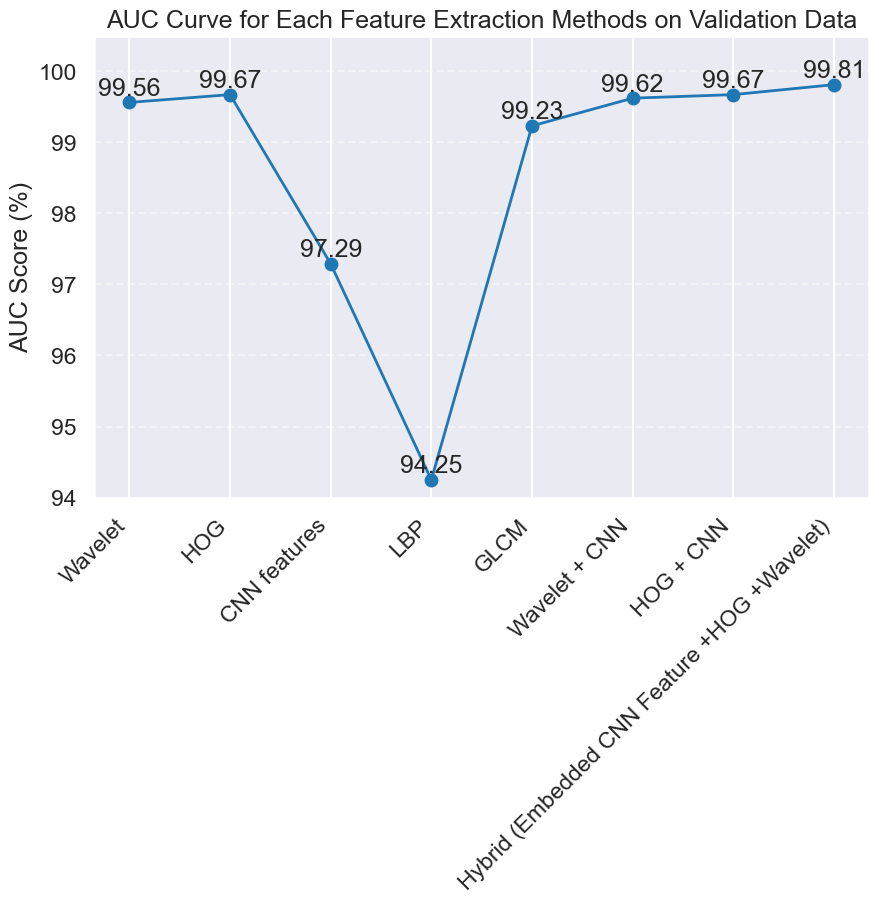

In [ ]:
methods = [
    "Wavelet",
    "HOG",
    "CNN features",
    "LBP",
    "GLCM",
    "Wavelet + CNN",
    "HOG + CNN",
    "Hybrid (Embedded CNN Feature +HOG +Wavelet)"
]

auc_scores = [99.56, 99.67, 97.29, 94.25, 99.23, 99.62, 99.67, 99.81]

plt.figure(figsize=(10, 6))

plt.plot(methods, auc_scores, marker='o', linewidth=2)

for x, y in zip(methods, auc_scores):
    plt.text(x, y + 0.1, f"{y}", ha='center')

plt.ylim(94, 100.5)

plt.xticks(rotation=45, ha="right")
plt.ylabel("AUC Score (%)")
plt.title("AUC Curve for Each Feature Extraction Methods on Validation Data")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


UNSEEN DATA BELOW BAR  CHART

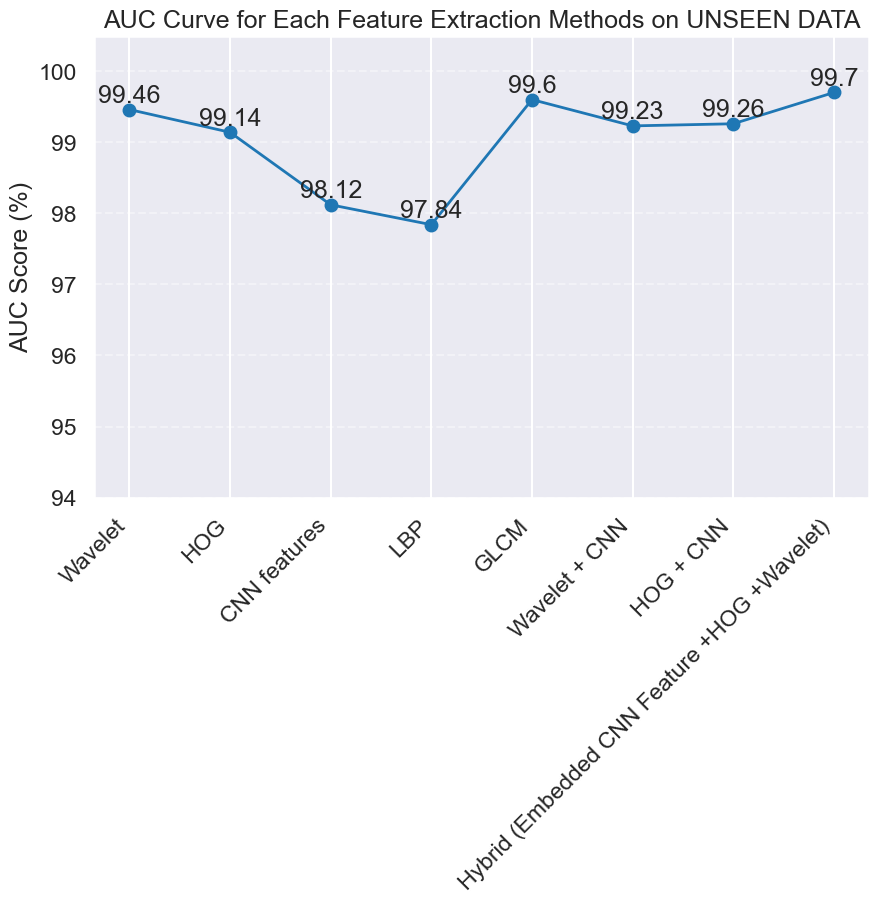

In [ ]:
methods = [
    "Wavelet",
    "HOG",
    "CNN features",
    "LBP",
    "GLCM",
    "Wavelet + CNN",
    "HOG + CNN",
    "Hybrid (Embedded CNN Feature +HOG +Wavelet)"
]

auc_scores = [99.46, 99.14, 98.12, 97.84, 99.60, 99.23, 99.26, 99.70]

plt.figure(figsize=(10, 6))

plt.plot(methods, auc_scores, marker='o', linewidth=2)

for x, y in zip(methods, auc_scores):
    plt.text(x, y + 0.1, f"{y}", ha='center')

plt.ylim(94, 100.5)

plt.xticks(rotation=45, ha="right")
plt.ylabel("AUC Score (%)")
plt.title("AUC Curve for Each Feature Extraction Methods on UNSEEN DATA")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()
